---
# Inicialización
---

In [1]:
## ==> Imports Basicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ==> Estadisticos
from scipy.stats import chisquare, chi2_contingency, loguniform, uniform, pointbiserialr, randint, uniform

## ==> Machine Learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


## ==> MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

## ==> Configuracion MLflow
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("no-pago-tc-experimentos")

## ==> Configuraciones pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

c:\Users\Dell\Documents\MASTER UNIVERSITARIO\TRABAJO FINAL 2\Desarrollo TFM\Desarrollo TC Default\entorno_tc_default\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [2]:
## ==> Constantes
SEED = 876
## ==> Semillas definidas
rng = np.random.RandomState(SEED)
np.random.seed(SEED)

---
# Entendimiento de los datos y del negocio
---

## Diccionario de datos — Default of Credit Card Clients Dataset (UCI)

| Variable | Tipo | Descripción |
|---|---|---|
| ID | Categórica | Identificador único de cada cliente |
| LIMIT_BAL | Numérica continua | Monto del crédito otorgado en dólares NT (incluye crédito individual y familiar/complementario) |
| SEX | Categórica nominal | Género del cliente (1=masculino, 2=femenino) |
| EDUCATION | Categórica ordinal | Nivel educativo (1=posgrado, 2=universidad, 3=secundaria, 4=otros, 5=desconocido, 6=desconocido) |
| MARRIAGE | Categórica nominal | Estado civil (1=casado, 2=soltero, 3=otros) |
| AGE | Numérica discreta | Edad del cliente en años |
| PAY_0 | Categórica ordinal | Estado de pago en septiembre de 2005 (-1=pago puntual, 1=retraso 1 mes, 2=retraso 2 meses, ... 8=retraso 8 meses, 9=retraso 9 meses o más) |
| PAY_2 | Categórica ordinal | Estado de pago en agosto de 2005 (escala igual a PAY_0) |
| PAY_3 | Categórica ordinal | Estado de pago en julio de 2005 (escala igual a PAY_0) |
| PAY_4 | Categórica ordinal | Estado de pago en junio de 2005 (escala igual a PAY_0) |
| PAY_5 | Categórica ordinal | Estado de pago en mayo de 2005 (escala igual a PAY_0) |
| PAY_6 | Categórica ordinal | Estado de pago en abril de 2005 (escala igual a PAY_0) |
| BILL_AMT1 | Numérica continua | Monto del estado de cuenta en septiembre de 2005 (dólar NT) |
| BILL_AMT2 | Numérica continua | Monto del estado de cuenta en agosto de 2005 (dólar NT) |
| BILL_AMT3 | Numérica continua | Monto del estado de cuenta en julio de 2005 (dólar NT) |
| BILL_AMT4 | Numérica continua | Monto del estado de cuenta en junio de 2005 (dólar NT) |
| BILL_AMT5 | Numérica continua | Monto del estado de cuenta en mayo de 2005 (dólar NT) |
| BILL_AMT6 | Numérica continua | Monto del estado de cuenta en abril de 2005 (dólar NT) |
| PAY_AMT1 | Numérica continua | Monto del pago realizado en septiembre de 2005 (dólar NT) |
| PAY_AMT2 | Numérica continua | Monto del pago realizado en agosto de 2005 (dólar NT) |
| PAY_AMT3 | Numérica continua | Monto del pago realizado en julio de 2005 (dólar NT) |
| PAY_AMT4 | Numérica continua | Monto del pago realizado en junio de 2005 (dólar NT) |
| PAY_AMT5 | Numérica continua | Monto del pago realizado en mayo de 2005 (dólar NT) |
| PAY_AMT6 | Numérica continua | Monto del pago realizado en abril de 2005 (dólar NT) |
| default.payment.next.month | Binaria (Target) | Variable objetivo — incumplimiento de pago el siguiente mes (1=sí incumple, 0=no incumple) |

**Fuente:** Yeh, I.C., & Lien, C.H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications*, 36(2), 2473-2480. UCI Machine Learning Repository.

**Nota:** El dataset original no contiene PAY_1 — el mes más reciente está codificado como PAY_0 (septiembre 2005), seguido de PAY_2 (agosto 2005). Esta numeración es propia del dataset original y se mantiene en el presente proyecto.

In [3]:
df_tc = pd.read_csv('../data/raw/UCI_Credit_Card.csv')
df_tc.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df_tc.shape

(30000, 25)

In [5]:
df_prep = df_tc.copy()

## Informacion del dataset

In [6]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Todas las variables son de tipo entero y flotantes. Entre las enteras tenemos Ordinales como __EDUCATION__ y Nominales como __SEX__

### Eliminar columnas inncesarias

In [7]:
df_prep.drop(columns=['ID'], inplace=True)

### Verificar nulos

In [8]:
df_prep.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

No se encontraron NULOS en el dataset

### Validar duplciados

In [9]:
df_prep.duplicated().sum()

np.int64(35)

Se encontraron duplicados en el dataset, los cuales deben ser removidos

In [10]:
df_prep = df_prep.drop_duplicates()

In [11]:
## ==> Tamaño
df_prep.shape

(29965, 24)

### Outliers

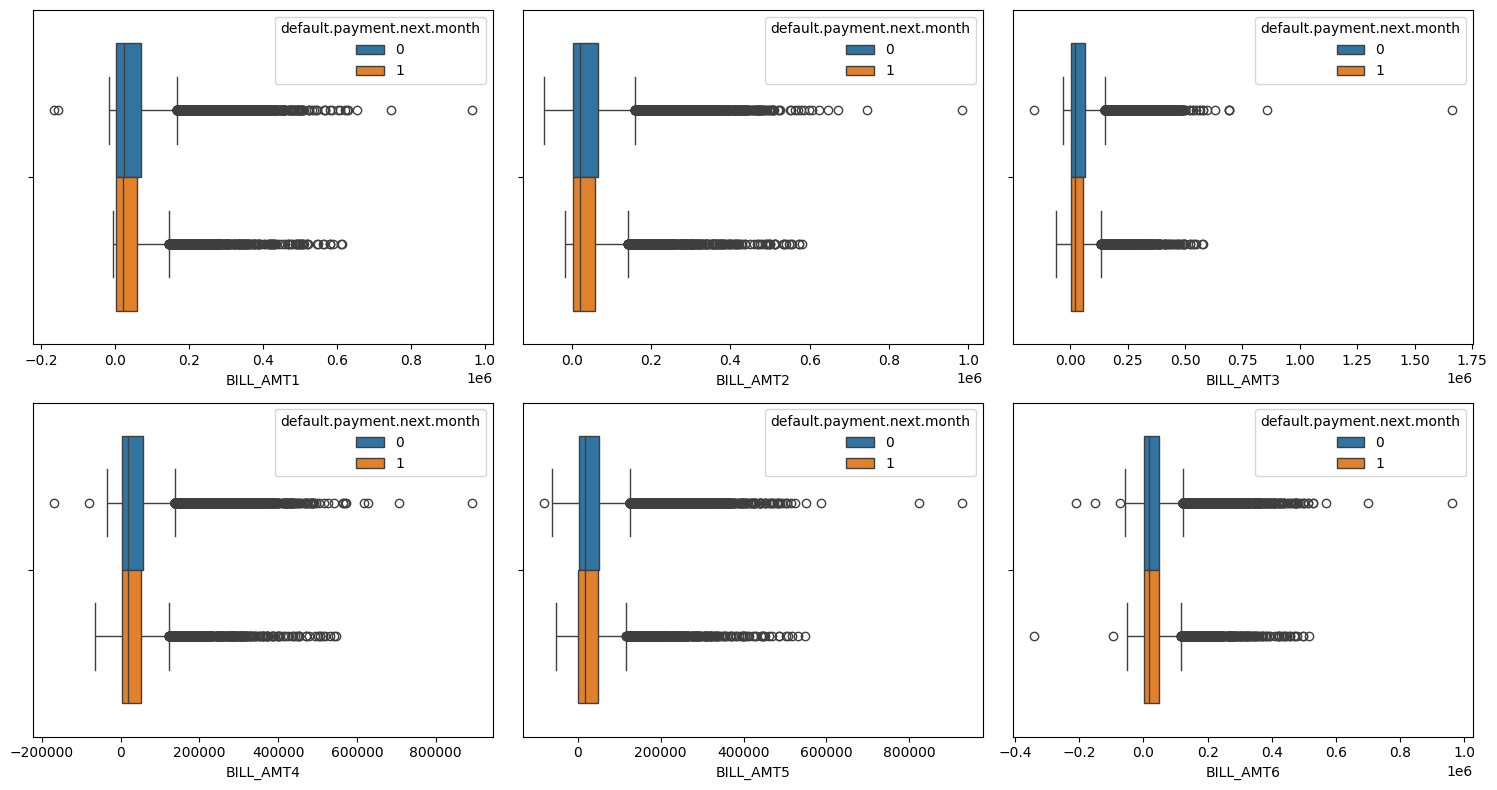

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(
    data=df_prep,
    x='BILL_AMT1',
    hue='default.payment.next.month',
    ax=ax[0, 0]
)
sns.boxplot(
    data=df_prep,
    x='BILL_AMT2',
    hue='default.payment.next.month',
    ax=ax[0, 1]
)
sns.boxplot(
    data=df_prep,
    x='BILL_AMT3',
    hue='default.payment.next.month',
    ax=ax[0, 2]
)

sns.boxplot(
    data=df_prep,
    x='BILL_AMT4',
    hue='default.payment.next.month',
    ax=ax[1, 0]
)
sns.boxplot(
    data=df_prep,
    x='BILL_AMT5',
    hue='default.payment.next.month',
    ax=ax[1, 1]
)
sns.boxplot(
    data=df_prep,
    x='BILL_AMT6',
    hue='default.payment.next.month',
    ax=ax[1, 2]
)

plt.tight_layout()
plt.show()

#### Determinando los niveles de outliers para BILL_AMT1

In [13]:
Q1 = df_prep['BILL_AMT1'].quantile(0.25)
Q3 = df_prep['BILL_AMT1'].quantile(0.75)
IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
lower_bound_e = Q1 - 3 * IQR
upper_bound_e = Q3 + 3 * IQR


#print(f'Lower Limit : {lower_bound}')
#print(f'Upper Limit : {upper_bound}')
print(f'Lower Limit extreme  : {lower_bound_e}')
print(f'Upper Limit extreme  : {upper_bound_e}')


Lower Limit extreme  : -187400.0
Upper Limit extreme  : 258255.0


In [14]:
df_prep[df_prep['BILL_AMT4'] <= -159521.0]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
3183,260000.0,1,3,1,48,0,0,0,0,-1,0,200716.0,203751.0,205530.0,-170000.0,171696.0,174151.0,8812.0,9158.0,0.0,497000.0,10000.0,7000.0,0


- Es fundamental realizar un tratamiento adecuado de los *outliers* dentro del dataset, ya que dependiendo del objetivo del análisis y del modelo seleccionado, estos pueden afectar significativamente el rendimiento.  
- En este caso particular, dado que se utilizará el modelo **KNeighborsClassifier**, el cual se basa en distancias para calcular similitudes, es necesario tratar los valores atípicos para evitar que distorsionen los resultados.  


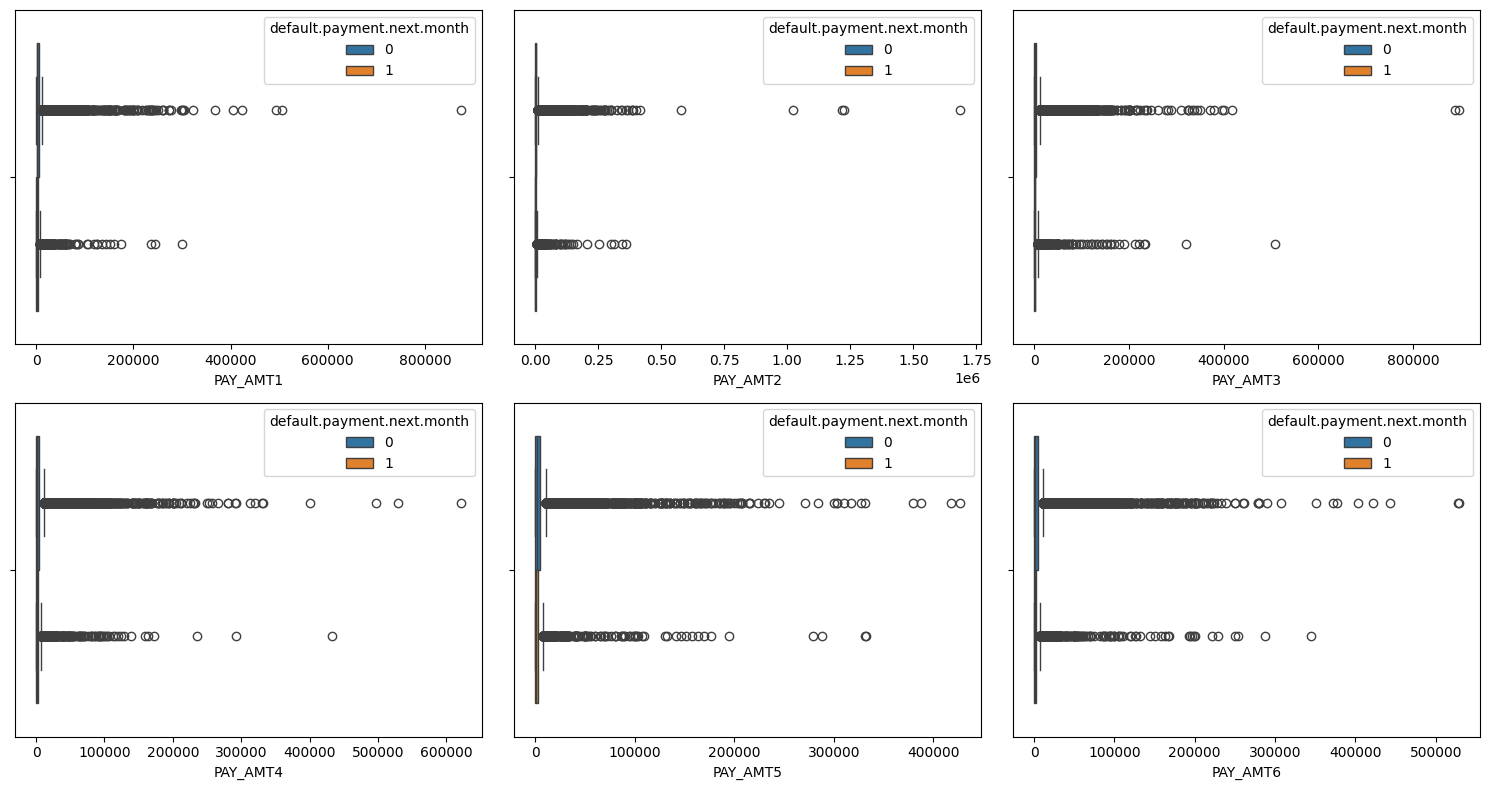

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(
    data=df_prep,
    x='PAY_AMT1',
    hue='default.payment.next.month',
    ax=ax[0, 0]
)
sns.boxplot(
    data=df_prep,
    x='PAY_AMT2',
    hue='default.payment.next.month',
    ax=ax[0, 1]
)
sns.boxplot(
    data=df_prep,
    x='PAY_AMT3',
    hue='default.payment.next.month',
    ax=ax[0, 2]
)

sns.boxplot(
    data=df_prep,
    x='PAY_AMT4',
    hue='default.payment.next.month',
    ax=ax[1, 0]
)
sns.boxplot(
    data=df_prep,
    x='PAY_AMT5',
    hue='default.payment.next.month',
    ax=ax[1, 1]
)
sns.boxplot(
    data=df_prep,
    x='PAY_AMT6',
    hue='default.payment.next.month',
    ax=ax[1, 2]
)

plt.tight_layout()
plt.show()

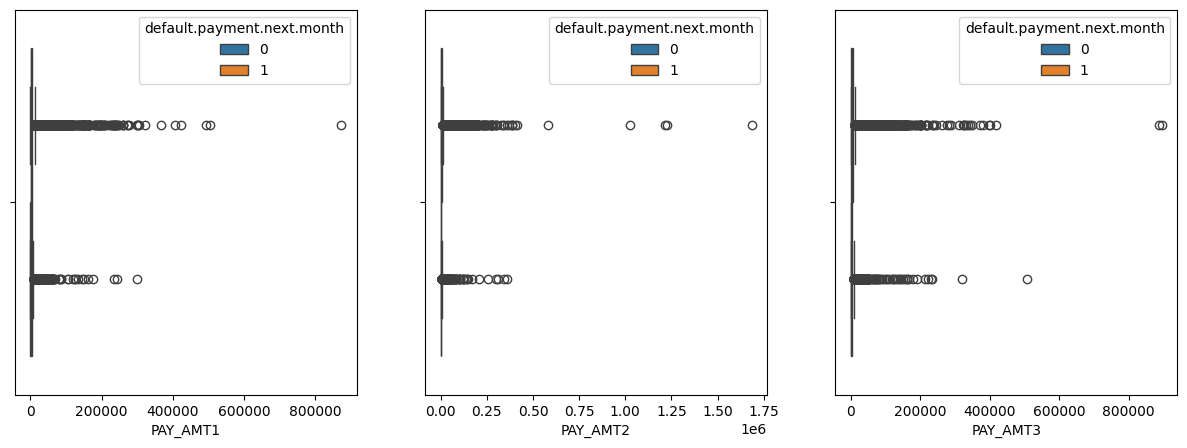

In [16]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT1',
    hue= 'default.payment.next.month',
    ax = ax[0]
)
sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT2',
    hue= 'default.payment.next.month',
    ax = ax[1]
)
sns.boxplot(
    data = df_prep,
    x = 'PAY_AMT3',
    hue= 'default.payment.next.month',
    ax = ax[2]
)
plt.show()

* Verificando otras variables, donde tambien encuentro outliers, sin embargo estos no son tan fuertes como BILL_AMT1, por lo que removerlo por ahora no es problema, tampoco hare tratamiento ya que es el comportamiento de un cliente y se debe evaluar el modelo de negocio.
* A menos que lo requiera un tratamiento, lo vere mas adelante, evaluando las metricas del modelo


## Analisis Exploratorio

### Analisis Univariado

In [17]:
df_bi = df_prep.copy()
df_bi.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [18]:
df_bi[['MARRIAGE', 'EDUCATION', 'SEX', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']] = df_bi[['MARRIAGE', 'EDUCATION', 'SEX', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']].astype('object')

__Medidas de tendencia central__

In [19]:
## ==> Medidas de tendencia Central
# Numericas
df_bi[[
    'LIMIT_BAL', 'AGE', 
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]].describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,35.487969,51283.009778,49236.366294,4.706792e+04,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014
std,129760.135222,9.219459,73658.132403,71195.567392,6.937135e+04,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3595.000000,3010.000000,2.711000e+03,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000
50%,140000.000000,34.000000,22438.000000,21295.000000,2.013500e+04,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67260.000000,64109.000000,6.020100e+04,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


* Comprobamos aun en mayor medida que las variables __LIMIT_BAL__, __AGE__, __BILL_AMT__, __PAY_AMT__ presentan una alta disperson y valores máximos muy elevados respecto a la media (outliers - atipicos) .

In [20]:
# Categoricas
df_bi[['MARRIAGE',	'EDUCATION','SEX', 'PAY_0',	'PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].describe()

,MARRIAGE,EDUCATION,SEX,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,29965,29965,29965,29965,29965,29965,29965,29965,29965
unique,4,7,2,11,11,11,11,10,10
top,2,2,2,0,0,0,0,0,0
freq,15945,14019,18091,14737,15730,15764,16455,16947,16286


Las variables categoricas tienen pocos valores unicos y estan concentradas en pocas categorias principales, lo que simplifica su tratamiento en el modelo y confirma su utilidad como predictores.

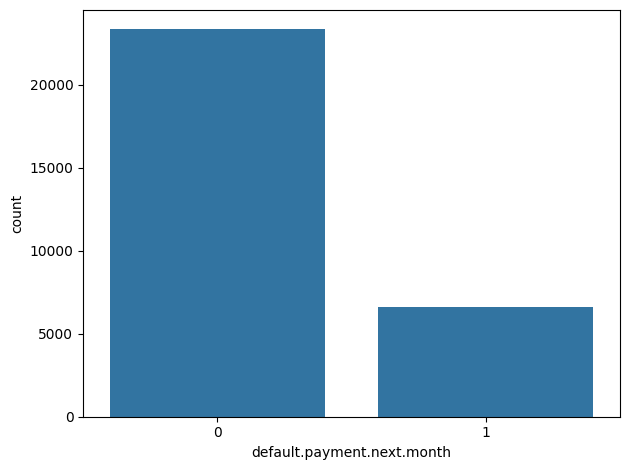

In [21]:
## ==> Validar la distribucion de los datos, en caso de que exista un desbalanceo
sns.countplot(
    data = df_bi,
    x = 'default.payment.next.month'
)
plt.tight_layout()
plt.show()

In [22]:
df_bi['default.payment.next.month'].value_counts(normalize=True)

default.payment.next.month
0    0.778742
1    0.221258
Name: proportion, dtype: float64

* Con la variable objetivo __default.payment.next.month__ tenemos un leve desbalanceo de clases, _0.77 para los que si pagan y 0.22 para los que no pagan_, es importante determinar el % de desbalanceo, ya que al momento de presentar resultados del modelo, debemos establecer un umbral de corte para las predicciones.

__Distribución de las variables__

Categoricas

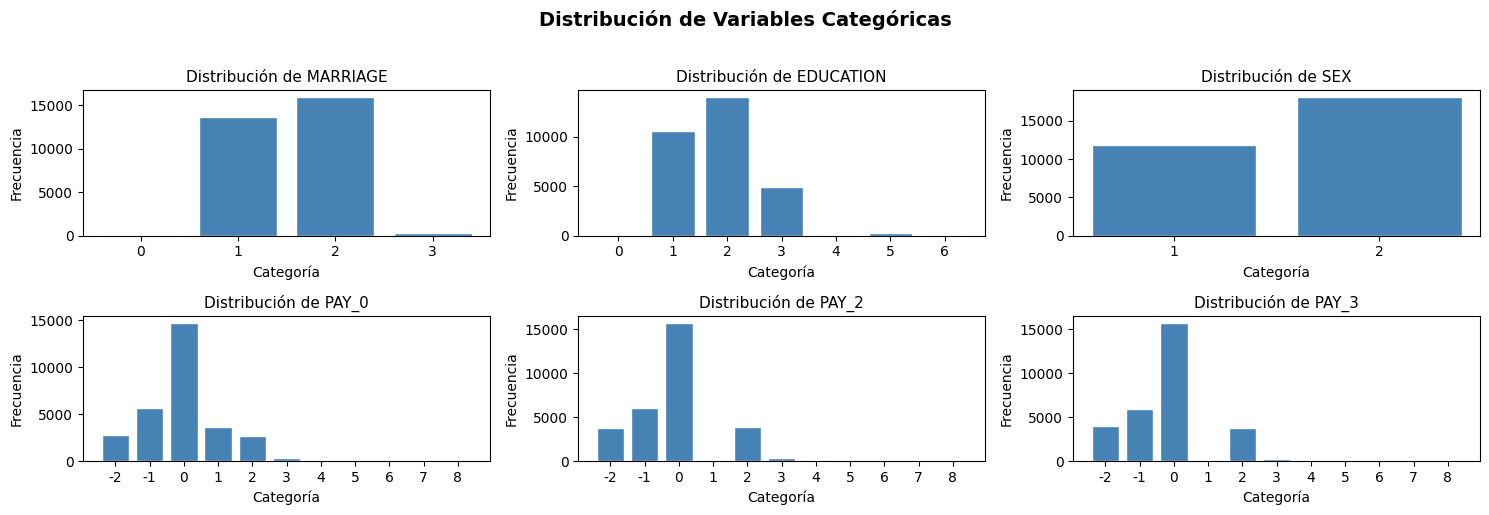

In [23]:
## ==> Distribucion de variables categoricas
cat_cols = ['MARRIAGE', 'EDUCATION', 'SEX', 'PAY_0', 'PAY_2', 'PAY_3']#'PAY_4', 'PAY_5', 'PAY_6'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_bi[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
for col in ['MARRIAGE', 'EDUCATION', 'SEX']:
    print(f'=== {col} ===')
    print(df_bi[col].value_counts().sort_index())
    print()

=== MARRIAGE ===
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64

=== EDUCATION ===
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64

=== SEX ===
SEX
1    11874
2    18091
Name: count, dtype: int64



In [25]:
## ==> Distribución completa de valores en variables PAY
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Obtener todos los valores únicos posibles
todos_valores = sorted(set(
    v for col in pay_cols 
    for v in df_bi[col].unique()
))

registros = []
for col in pay_cols:
    counts = df_bi[col].value_counts()
    fila = {'Variable': col}
    for valor in todos_valores:
        fila[f'Valor {valor}'] = counts.get(valor, 0)
    registros.append(fila)

df_distribucion = pd.DataFrame(registros)
df_distribucion

,Variable,Valor -2,Valor -1,Valor 0,Valor 1,Valor 2,Valor 3,Valor 4,Valor 5,Valor 6,Valor 7,Valor 8
0,PAY_0,2750,5682,14737,3667,2666,322,76,26,11,9,19
1,PAY_2,3752,6046,15730,28,3926,326,99,25,12,20,1
2,PAY_3,4055,5934,15764,4,3819,240,75,21,23,27,3
3,PAY_4,4318,5683,16455,2,3159,180,68,35,5,58,2
4,PAY_5,4516,5535,16947,0,2626,178,83,17,4,58,1
5,PAY_6,4865,5736,16286,0,2766,184,48,13,19,46,2


Hallazgos
* Para las variables de PAY_2 hasta PAY_6 existe muy pocos registros con "Valor 1" indicando que el cliente no se retraso 1 mes, podemos sacar una hipotesis, y es que el area de cobranzas pudo haber perdonado la mora de estos clientes 
* EDUCATION valores 0, 5 y 6 no documentados oficialmente es muy probable que necesiten una reclasificacion
* MARRIAGE valor 0 no documentado oficialmente, tambien puede necesitar una reclasificacion.
* En el dataset original se llama PAY_0, renombrado a PAY_1 para consistencia con BILL_AMT1 y PAY_AMT1.

Numericas

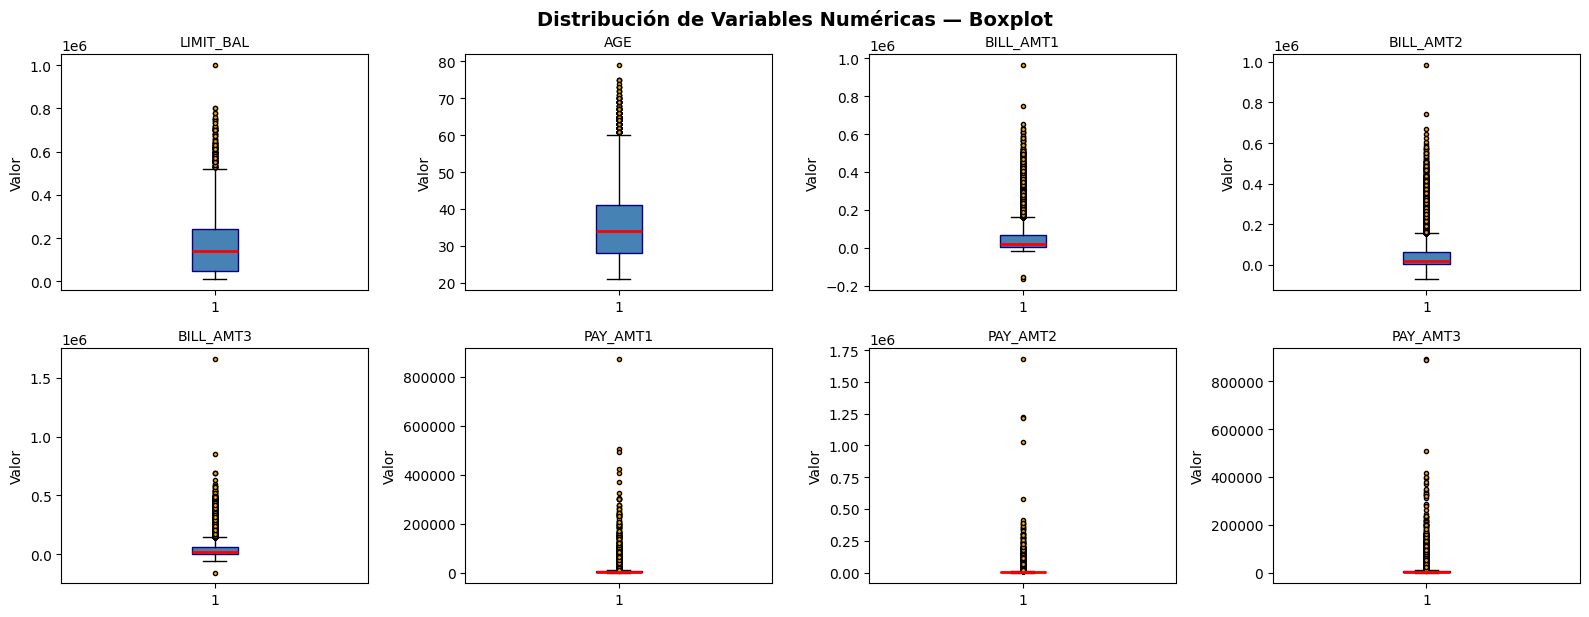

In [26]:
## ==> Boxplot de variables numericas
num_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',# 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3'#, 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_bi[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Valor')

# Ocultar subplots vacios
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas — Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

A simple vista se observan que los valores estan muy dispersos, evidenciando outliers

### Analisis multivariado

Variables Categoricas

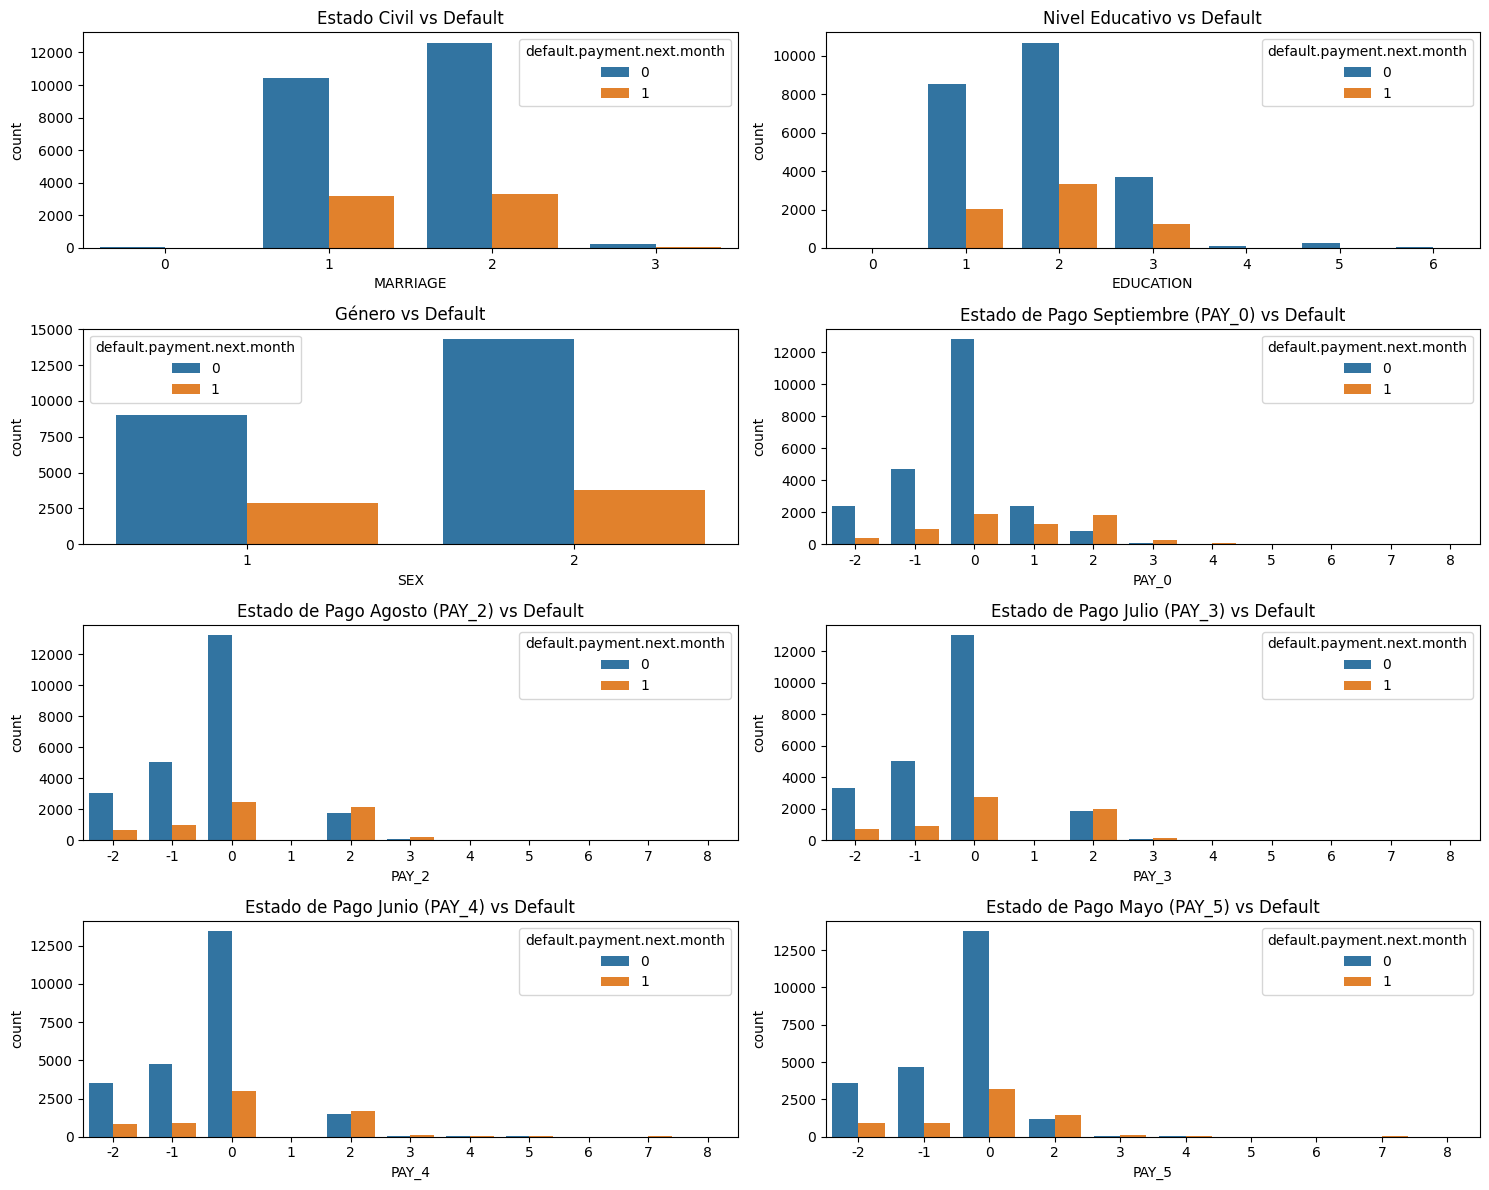

In [27]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 12))

sns.countplot(
    data=df_bi,
    x='MARRIAGE',
    hue='default.payment.next.month',
    ax=ax[0][0]
)
ax[0][0].set_title('Estado Civil vs Default')

sns.countplot(
    data=df_bi,
    x='EDUCATION',
    hue='default.payment.next.month',
    ax=ax[0][1]
)
ax[0][1].set_title('Nivel Educativo vs Default')

sns.countplot(
    data=df_bi,
    x='SEX',
    hue='default.payment.next.month',
    ax=ax[1][0]
)
ax[1][0].set_title('Género vs Default')

sns.countplot(
    data=df_bi,
    x='PAY_0',
    hue='default.payment.next.month',
    ax=ax[1][1]
)
ax[1][1].set_title('Estado de Pago Septiembre (PAY_0) vs Default')

sns.countplot(
    data=df_bi,
    x='PAY_2',
    hue='default.payment.next.month',
    ax=ax[2][0]
)
ax[2][0].set_title('Estado de Pago Agosto (PAY_2) vs Default')

sns.countplot(
    data=df_bi,
    x='PAY_3',
    hue='default.payment.next.month',
    ax=ax[2][1]
)
ax[2][1].set_title('Estado de Pago Julio (PAY_3) vs Default')

sns.countplot(
    data=df_bi,
    x='PAY_4',
    hue='default.payment.next.month',
    ax=ax[3][0]
)
ax[3][0].set_title('Estado de Pago Junio (PAY_4) vs Default')

sns.countplot(
    data=df_bi,
    x='PAY_5',
    hue='default.payment.next.month',
    ax=ax[3][1]
)
ax[3][1].set_title('Estado de Pago Mayo (PAY_5) vs Default')

plt.tight_layout()
plt.show()

* Podemos determinar que a medida que el cliente se retrasa en el pago (PAY_0 - PAY_2 - PAY_3... la probabilidad de que un cliente no pague es mas alta)
* El cliente que tenga como educacion __postgrado y univerisdad__ aumentan las probabilidades de que pague y no caiga en morosidad
* En cuanto al estado civil, no se observa un patron claro que diferencia entre quienes pagan y quienes no.
 __Conclusion :__ Podemos inferir que estas variables categoricas aportan un valor significativo para el modelo a usar, pues se verifica que existe segmentacion significativa para clientes que pagaron y no pagaron  

### Variables Numericas

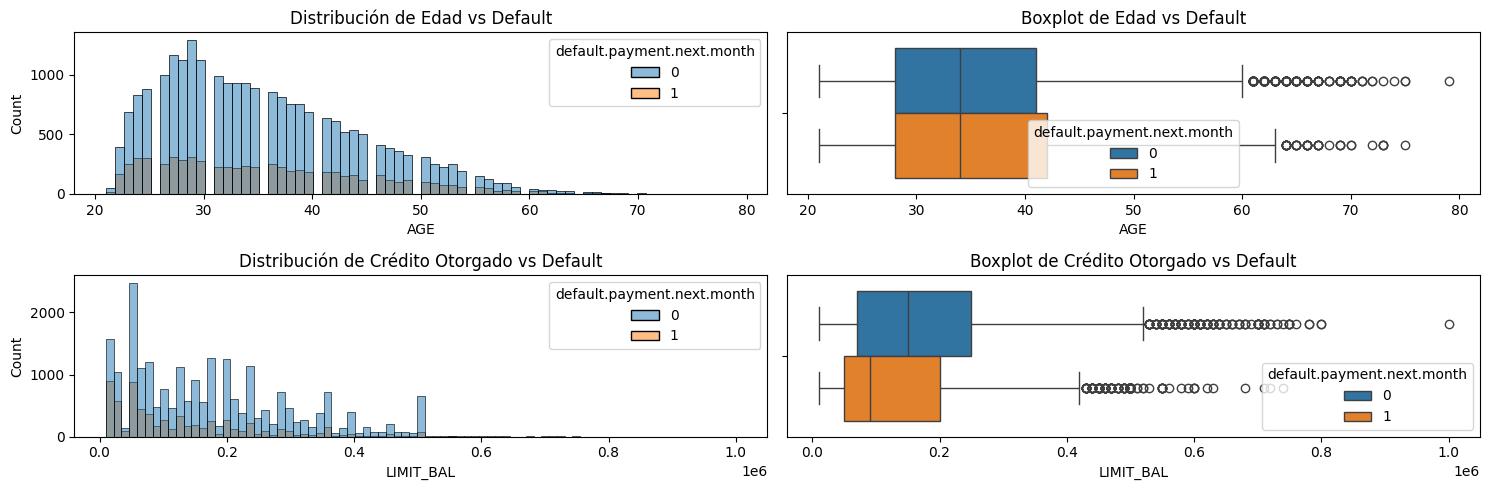

In [28]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,5))

sns.histplot(
    data=df_bi,
    x='AGE',
    hue='default.payment.next.month',
    ax=ax[0][0]
)
ax[0][0].set_title('Distribución de Edad vs Default')

sns.boxplot(
    data=df_bi,
    x='AGE',
    hue='default.payment.next.month',
    ax=ax[0][1]
)
ax[0][1].set_title('Boxplot de Edad vs Default')

sns.histplot(
    data=df_bi,
    x='LIMIT_BAL',
    hue='default.payment.next.month',
    ax=ax[1][0]
)
ax[1][0].set_title('Distribución de Crédito Otorgado vs Default')

sns.boxplot(
    data=df_bi,
    x='LIMIT_BAL',
    hue='default.payment.next.month',
    ax=ax[1][1]
)
ax[1][1].set_title('Boxplot de Crédito Otorgado vs Default')

plt.tight_layout()
plt.show()

* La mayoría de clientes se concentra entre los 25 y 45 años, independientemente si paga o no paga, se observa marginalmente que algunos clientes entre 40 y 45 años suele no pagar 

* En cuanto al monto de crédito, los clientes que menos creditos son propensos a no pagar su tarjeta de credito

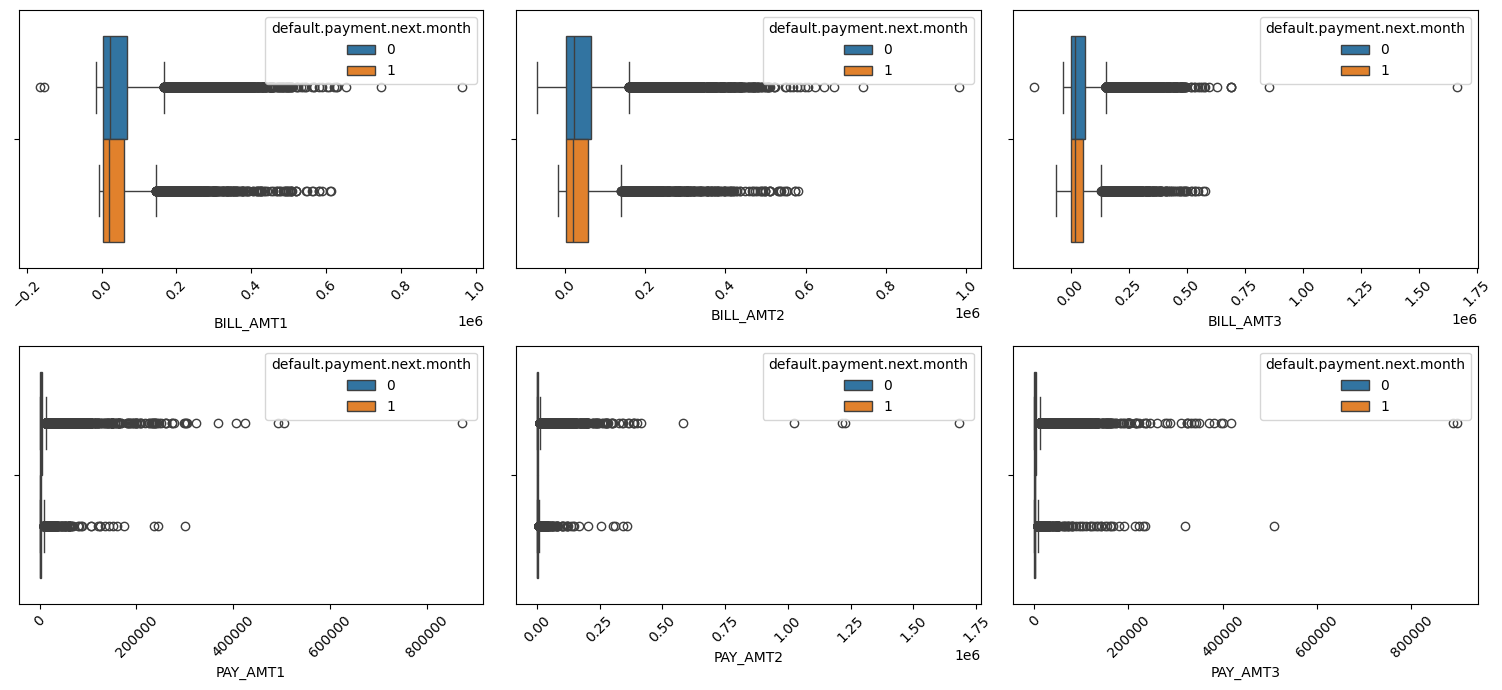

In [29]:
fig, ax = plt.subplots(2,3, figsize=(15,7))
sns.boxplot(data = df_bi, x = 'BILL_AMT1', hue = 'default.payment.next.month',  ax = ax[0][0])
sns.boxplot( data = df_bi, x = 'BILL_AMT2', hue = 'default.payment.next.month', ax = ax[0][1])
sns.boxplot( data = df_bi, x = 'BILL_AMT3', hue = 'default.payment.next.month', ax = ax[0][2])
sns.boxplot( data = df_bi, x = 'PAY_AMT1', hue = 'default.payment.next.month',  ax = ax[1][0])
sns.boxplot( data = df_bi, x = 'PAY_AMT2', hue = 'default.payment.next.month',  ax = ax[1][1])
sns.boxplot( data = df_bi, x = 'PAY_AMT3', hue = 'default.payment.next.month',  ax = ax[1][2])
for axes in ax.flat:
  axes.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

* Se observan outliers muy altos tanto en facturación como en pagos, lo que indica clientes con montos extraordinarios que no representan a la mayoría.

* La mayoría de clientes se concentra en valores bajos, y en ese rango se distingue que quienes tienen facturas más bajas y pagos reducidos tienden a presentar mayor morosidad.

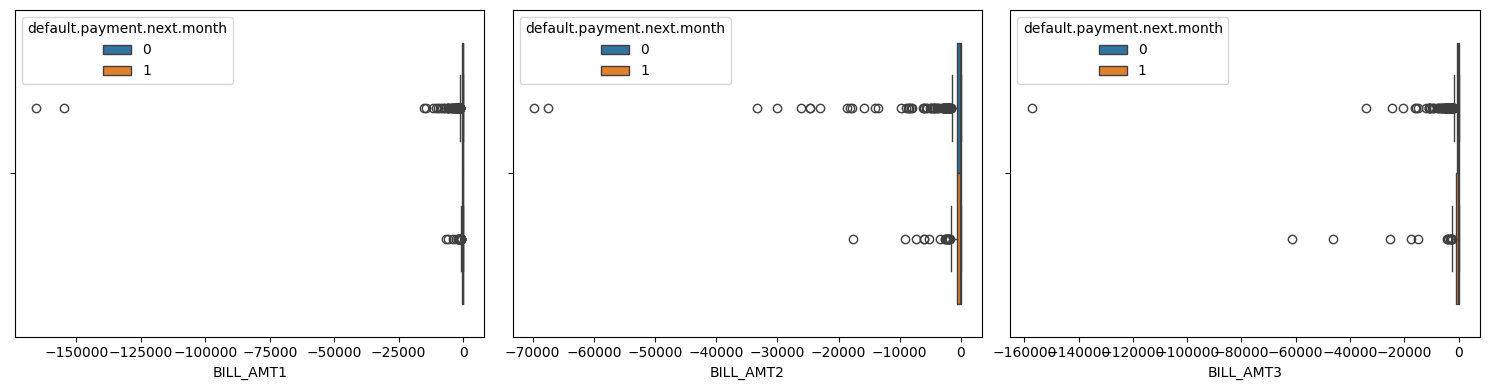

In [30]:
## ==> Validando valores negativos, SALDOS A FAVOR DEL CLIENTE
fig, ax = plt.subplots(1,3, figsize=(15,4))
sns.boxplot(data = df_bi.query("BILL_AMT1 < 0"), x = 'BILL_AMT1', hue = 'default.payment.next.month', ax = ax[0])
sns.boxplot(data = df_bi.query("BILL_AMT2 < 0"), x = 'BILL_AMT2', hue = 'default.payment.next.month', ax = ax[1])
sns.boxplot(data = df_bi.query("BILL_AMT3 < 0"), x = 'BILL_AMT3', hue = 'default.payment.next.month', ax = ax[2])
plt.tight_layout()
plt.show()

* Algunos importes de estados son negativos, esto conlleva a que el cliente en un mes determinado pago de mas, por lo que su cuenta para ellos saldra favorable, por ejemplo si tiene : -5000 esto es un saldo a su favor. Por lo que esto no es un error, sino parte de la naturaleza de un estado de cuenta
---

### Correlaciones

In [31]:
num_var = ['LIMIT_BAL', 'AGE', 
           'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
           'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
           'default.payment.next.month']

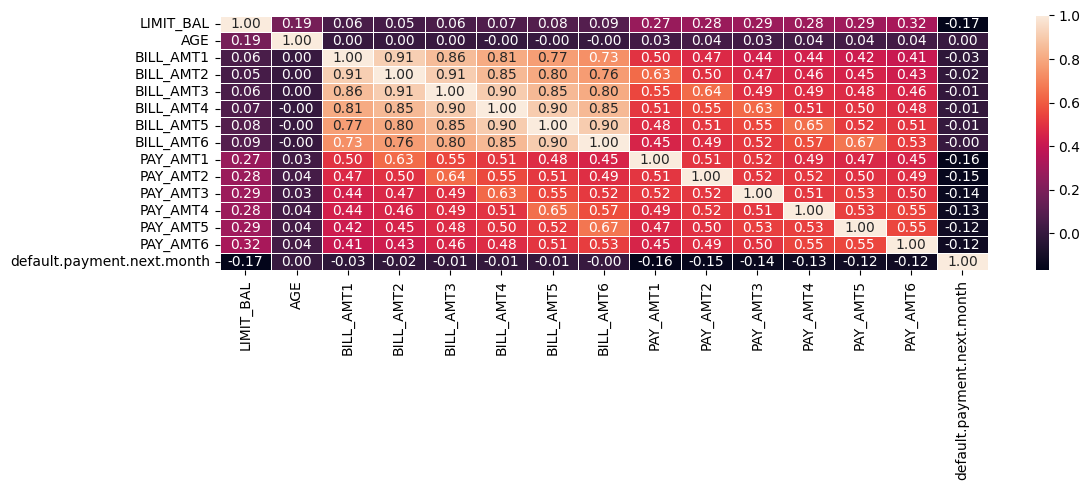

In [32]:
plt.figure(figsize=(12,5))
correlacion = df_bi[num_var].corr(method = "spearman") # Usamos spearman para la NO LINEALIDAD y porque no es sensible a outliers
sns.heatmap(data = correlacion, annot=True, fmt= ".2f", linewidths=.5)
plt.tight_layout()
plt.show()

In [33]:
cat_var = [
    'MARRIAGE', 'EDUCATION', 'SEX',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
]

In [34]:
## ==> Chi Cuadrado
for column in cat_var:
    print(f'Variable : {column}')
    contingency_table = pd.crosstab(df_bi[column], df_bi['default.payment.next.month'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi- cuadrado: {chi2}')
    print(f'p-valor: {p_value}')
    print(f'Grados de libertad: {dof}')
    if p_value > 0.05 :
        print('Variable NO SIGNIFICATIVA --> Debe ser eliminada')
    else :
        print('Variable significativa')
    print('******')

Variable : MARRIAGE
Chi- cuadrado: 35.019394664766885
p-valor: 1.2068096207628454e-07
Grados de libertad: 3
Variable significativa
******
Variable : EDUCATION
Chi- cuadrado: 163.26642524923153
p-valor: 1.2036191660210255e-32
Grados de libertad: 6
Variable significativa
******
Variable : SEX
Chi- cuadrado: 47.13112674398994
p-valor: 6.6392887616462755e-12
Grados de libertad: 1
Variable significativa
******
Variable : PAY_0
Chi- cuadrado: 5363.502647375973
p-valor: 0.0
Grados de libertad: 10
Variable significativa
******
Variable : PAY_2
Chi- cuadrado: 3470.4198386500702
p-valor: 0.0
Grados de libertad: 10
Variable significativa
******
Variable : PAY_3
Chi- cuadrado: 2618.4629580734186
p-valor: 0.0
Grados de libertad: 10
Variable significativa
******
Variable : PAY_4
Chi- cuadrado: 2337.2134544953765
p-valor: 0.0
Grados de libertad: 10
Variable significativa
******
Variable : PAY_5
Chi- cuadrado: 2193.782819305689
p-valor: 0.0
Grados de libertad: 9
Variable significativa
******
Variable 

In [35]:
## ==> Chi Cuadrado
pay_vars = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
other_vars = ['MARRIAGE', 'EDUCATION', 'SEX']

# Variables individuales
for column in other_vars:
    print(f'Variable: {column}')
    contingency_table = pd.crosstab(df_bi[column], df_bi['default.payment.next.month'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi-cuadrado: {chi2:.4f}')
    print(f'p-valor: {p_value:.4f}')
    print(f'Grados de libertad: {dof}')
    if p_value > 0.05:
        print('Variable NO SIGNIFICATIVA --> Debe ser eliminada')
    else:
        print('Variable significativa')
    print('******')

# Variables PAY agrupadas
print('=== Variables PAY_1 a PAY_6 ===')
pay_significativas = []
pay_no_significativas = []

for column in pay_vars:
    contingency_table = pd.crosstab(df_bi[column], df_bi['default.payment.next.month'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    if p_value <= 0.05:
        pay_significativas.append(column)
    else:
        pay_no_significativas.append(column)

if len(pay_significativas) == len(pay_vars):
    print(f'Todas las variables PAY_1 a PAY_6 \n son significativas (p-valor <= 0.05)')
elif len(pay_no_significativas) == len(pay_vars):
    print(f'Ninguna variable PAY_1 a PAY_6 es significativa')
else:
    print(f'Variables significativas: {pay_significativas}')
    print(f'Variables NO significativas: {pay_no_significativas}')
print('******')

Variable: MARRIAGE
Chi-cuadrado: 35.0194
p-valor: 0.0000
Grados de libertad: 3
Variable significativa
******
Variable: EDUCATION
Chi-cuadrado: 163.2664
p-valor: 0.0000
Grados de libertad: 6
Variable significativa
******
Variable: SEX
Chi-cuadrado: 47.1311
p-valor: 0.0000
Grados de libertad: 1
Variable significativa
******
=== Variables PAY_1 a PAY_6 ===
Todas las variables PAY_1 a PAY_6 
 son significativas (p-valor <= 0.05)
******


* La tecnica-chi cuadrado se usa para este tipos de variables ordinales y nominales, dandonos de resultados que todas nuestras variables son altamente significativas para el modelo

In [36]:
## == > Volviendo a poner como INT estas variables
df_bi[['MARRIAGE', 'EDUCATION', 'SEX', 
       'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'default.payment.next.month']] = df_bi[['MARRIAGE', 'EDUCATION', 'SEX',
                                               'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                                               'default.payment.next.month']].astype(int)

---
# Preparación de los datos
---

In [37]:
df_preparacion = df_bi.copy()

In [38]:
## Renombramiento de categorias no documentadas
df_preparacion = df_preparacion.rename(columns={'PAY_0': 'PAY_1'})

# EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
# MARRIAGE: Marital status (1=married, 2=single, 3=others)

df_preparacion['EDUCATION'] = df_preparacion['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_preparacion['MARRIAGE'] = df_preparacion['MARRIAGE'].replace({0: 3})

### Creacion de nuevas variables

In [39]:
df_feature = df_preparacion.copy()

In [40]:
# Utilización del crédito (riesgo de sobreuso)
df_feature['CREDIT_UTIL1'] = np.where(
    df_feature['LIMIT_BAL'] == 0,
    0,
    df_feature['BILL_AMT1'] / df_feature['LIMIT_BAL']
)

pay_cols = ['PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Mora histórica (intensidad y presencia) - 6 meses
# clip(lower=0) ignora valores -2 y -1 que no representan mora real
df_feature['DEMORA_SUM'] = df_feature[pay_cols].clip(lower=0).sum(axis=1)
df_feature['DEMORA_MAX'] = df_feature[pay_cols].clip(lower=0).max(axis=1)

# Meses al día: meses donde PAY <= 0 (sin mora activa)
df_feature['MESES_AL_DIA'] = (df_feature[pay_cols] <= 0).sum(axis=1)

# Diferencia entre el monto del último mes (BILL_AMT1) y el menor de los 6 meses
df_feature['VARIACION_TOTAL_CUENTA'] = df_feature['BILL_AMT1'] - df_feature[
    ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
].min(axis=1)

Se crearon nuevas variables para capturar mejor el comportamiento del cliente:  

- **CREDIT_UTIL1**: relación entre saldo y crédito total (riesgo de sobreuso).  
- **DEMORA_SUM, DEMORA_MAX y MESES_AL_DIA**: resumen de intensidad y frecuencia de atrasos.  
- **VARIACION_TOTAL_CUENTA**: diferencia entre el último saldo y el mínimo de los 6 meses previos.  


In [41]:
df_feature.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0.195650,4,2,4,3913.0
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.022350,4,2,4,957.0
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.324878,0,0,6,15680.0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.939800,0,0,6,18676.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.172340,0,0,6,2947.0


In [42]:
num_var = [
           'CREDIT_UTIL1', 'VARIACION_TOTAL_CUENTA', 'default.payment.next.month']

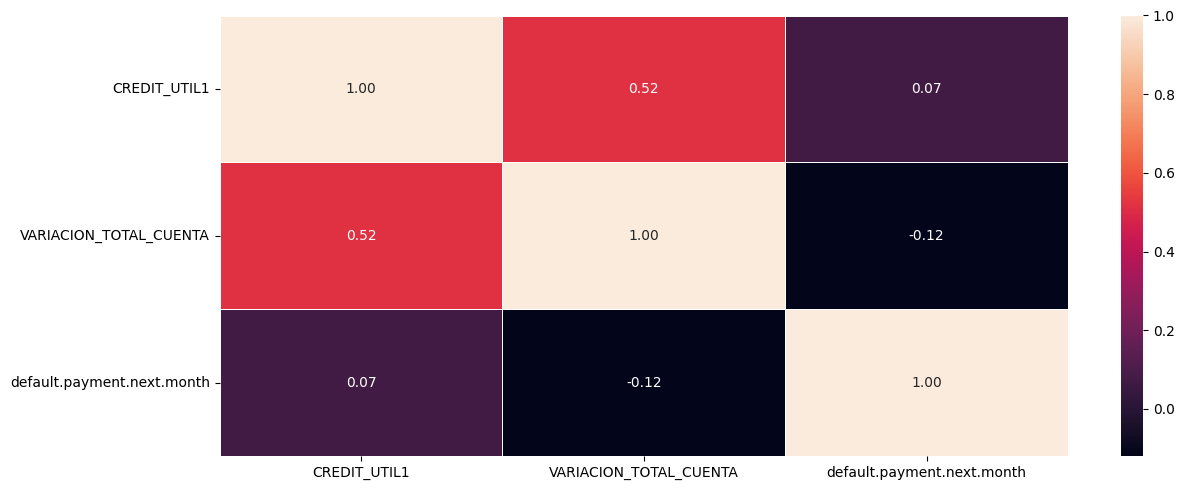

In [43]:
plt.figure(figsize=(13,5))
correlacion = df_feature[num_var].corr(method='spearman')
sns.heatmap(data = correlacion, annot=True, fmt= ".2f", linewidths=.5)
plt.tight_layout()
plt.show()


- Ambas variables no tienen correlación alta con la variable objetivo `default.payment.next.month` (< 0.15), pero sí aportan nuevas perspectivas útiles para el modelo, especialmente en el análisis del riesgo de sobreuso y la variación de deuda.  


In [44]:
cat_var = [
    'DEMORA_SUM',	'DEMORA_MAX','MESES_AL_DIA'
]
## ==> Chi Cuadrado
for column in cat_var:
    contingency_table = pd.crosstab(df_feature[column], df_feature['default.payment.next.month'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'Chi- cuadrado: {chi2}')
    print(f'p-valor: {p_value}')
    print(f'Grados de libertad: {dof}')
    if p_value > 0.05 :
        print('Variable NO SIGNIFICATIVA --> Debe ser eliminada')
    else :
        print('Variable significativa')
    print('******')

Chi- cuadrado: 5216.011470987294
p-valor: 0.0
Grados de libertad: 34
Variable significativa
******
Chi- cuadrado: 4347.2543444247385
p-valor: 0.0
Grados de libertad: 8
Variable significativa
******
Chi- cuadrado: 4967.908761497648
p-valor: 0.0
Grados de libertad: 6
Variable significativa
******


Las tres variables aportan información relevante para explicar la probabilidad de no pago (`default.payment.next.month`). Ninguna debe ser eliminada, ya que todas presentan asociación estadísticamente significativa.

In [45]:
target = 'default.payment.next.month'
num_vars = [c for c in df_feature.columns if c not in [target]]

corrs = {}
for col in num_vars:
    r, p = pointbiserialr(df_feature[target], df_feature[col])
    corrs[col] = {'point_biserial_r': r, 'p_value': p}

pd.DataFrame(corrs).T.sort_values('point_biserial_r', ascending=False)

,point_biserial_r,p_value
DEMORA_SUM,0.376004,0.000000e+00
DEMORA_MAX,0.370398,0.000000e+00
PAY_1,0.324964,0.000000e+00
PAY_2,0.263656,0.000000e+00
PAY_3,0.235230,0.000000e+00
PAY_4,0.216551,6.758799e-315
PAY_5,0.204059,4.212965e-279
PAY_6,0.186740,2.838076e-233
CREDIT_UTIL1,0.086107,2.023919e-50
EDUCATION,0.033862,4.545740e-09


* Se utiliza **point biserial correlation** porque la variable objetivo `default.payment.next.month` es **binaria**, y permite medir de forma adecuada la relación entre esta y las variables **numéricas**.
---

In [46]:
nominal = ['MARRIAGE', 'SEX']                           # sin orden → One-Hot
ordinal = ['EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3',     # con orden → numéricas
           'PAY_4', 'PAY_5', 'PAY_6']

df_feature_dummies = pd.get_dummies(
    df_feature,
    columns=nominal,
    drop_first=False,
    dtype=int
)

rename_dict = {
    "MARRIAGE_1": "Civil_Casado",
    "MARRIAGE_2": "Civil_Soltero",
    "MARRIAGE_3": "Civil_Otros",
    "SEX_1": "Sexo_Masculino",
    "SEX_2": "Sexo_Femenino"
}

df_feature_dummies = df_feature_dummies.rename(columns=rename_dict)
df_feature_dummies.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,20000.0,2,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0.195650,4,2,4,3913.0,1,0,0,0,1
1,120000.0,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.022350,4,2,4,957.0,0,1,0,0,1
2,90000.0,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.324878,0,0,6,15680.0,0,1,0,0,1
3,50000.0,2,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.939800,0,0,6,18676.0,1,0,0,0,1
4,50000.0,2,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.172340,0,0,6,2947.0,1,0,0,1,0


---
# Modelamiento - Evaluación
---

In [47]:
df_ml_rf = df_feature_dummies.copy()
df_ml_rf.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,20000.0,2,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0.195650,4,2,4,3913.0,1,0,0,0,1
1,120000.0,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.022350,4,2,4,957.0,0,1,0,0,1
2,90000.0,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.324878,0,0,6,15680.0,0,1,0,0,1
3,50000.0,2,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.939800,0,0,6,18676.0,1,0,0,0,1
4,50000.0,2,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.172340,0,0,6,2947.0,1,0,0,1,0


Los modelos utilizados para el análisis de riesgo crediticio fueron:  
- **RandomForestClassifier**: un algoritmo de ensamblado basado en múltiples árboles de decisión, robusto frente a outliers y capaz de capturar relaciones no lineales.  
- **KNeighborsClassifier (KNN)**: un modelo basado en la similitud entre instancias, útil para evaluar cómo las características de un cliente se relacionan con sus vecinos más cercanos.  
- **Logistic Regression**: un modelo lineal ampliamente utilizado en riesgo crediticio, que permite interpretar directamente el peso de cada variable sobre la probabilidad de incumplimiento.  

A continuación, se presenta el desarrollo y análisis paso a paso de cada modelo, incluyendo la optimización de hiperparámetros, métricas de desempeño, ajuste de umbrales y la interpretación de variables más relevantes.

In [48]:
TARGET = 'default.payment.next.month'

## RandomForestClassifier

In [49]:
#df_ml_rf = df_feature.copy()
#df_ml_rf.head()

In [50]:
# nominal = ['MARRIAGE', 'SEX']                           # sin orden → One-Hot
# ordinal = ['EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3',     # con orden → numéricas
#            'PAY_4', 'PAY_5', 'PAY_6']

# df_base = pd.get_dummies(
#     df_ml_rf,
#     columns=nominal,
#     drop_first=False,
#     dtype=int
# )

# rename_dict = {
#     "MARRIAGE_1": "Civil_Casado",
#     "MARRIAGE_2": "Civil_Soltero",
#     "MARRIAGE_3": "Civil_Otros",
#     "SEX_1": "Sexo_Masculino",
#     "SEX_2": "Sexo_Femenino"
# }

# df_base = df_base.rename(columns=rename_dict)
# df_base.head()

In [51]:
# df_ml_rf = df_base.copy()

In [52]:
X = df_ml_rf.drop(columns=['default.payment.next.month'])
y = df_ml_rf['default.payment.next.month']

In [53]:
X.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,20000.0,2,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,0.195650,4,2,4,3913.0,1,0,0,0,1
1,120000.0,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,0.022350,4,2,4,957.0,0,1,0,0,1
2,90000.0,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0.324878,0,0,6,15680.0,0,1,0,0,1
3,50000.0,2,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0.939800,0,0,6,18676.0,1,0,0,0,1
4,50000.0,2,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0.172340,0,0,6,2947.0,1,0,0,1,0


In [54]:
x_train, x_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state =SEED , stratify= y)

In [55]:
x_train_ml = pd.concat([x_train, y_train], axis = 1)
x_train_ml.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino,default.payment.next.month
22697,500000.0,2,35,0,0,0,0,0,0,286595.0,292813.0,302966.0,300000.0,400000.0,0.0,11000.0,14846.0,6000.0,100000.0,0.0,279260.0,0.573190,0,0,6,286595.0,1,0,0,0,1,0
21794,90000.0,1,25,0,0,0,0,0,0,14550.0,15205.0,15523.0,15850.0,15849.0,17309.0,2000.0,2000.0,5000.0,2000.0,2000.0,5000.0,0.161667,0,0,6,0.0,0,1,0,0,1,0
10861,110000.0,2,29,2,2,4,4,3,2,600.0,600.0,600.0,600.0,300.0,150.0,0.0,0.0,0.0,0.0,0.0,921.0,0.005455,17,4,0,450.0,0,1,0,0,1,1
19944,500000.0,1,34,-1,-1,-1,-1,0,-1,4677.0,6187.0,4775.0,31188.0,5827.0,3637.0,6187.0,4775.0,31188.0,0.0,4119.0,7390.0,0.009354,0,0,6,1040.0,0,1,0,0,1,0
19259,210000.0,2,29,-1,-1,-1,-1,-1,-1,1778.0,224.0,2018.0,0.0,1118.0,1858.0,226.0,2031.0,0.0,1118.0,1858.0,620.0,0.008467,0,0,6,1778.0,0,1,0,0,1,0


#### Encontrando los estimadores mas optimos

[0.6554077147229206, 0.6964177320049597, 0.7213502991709354, 0.7396047481028353, 0.7539099978015645, 0.7587985096487846, 0.7610776594656434, 0.7621356052430706]


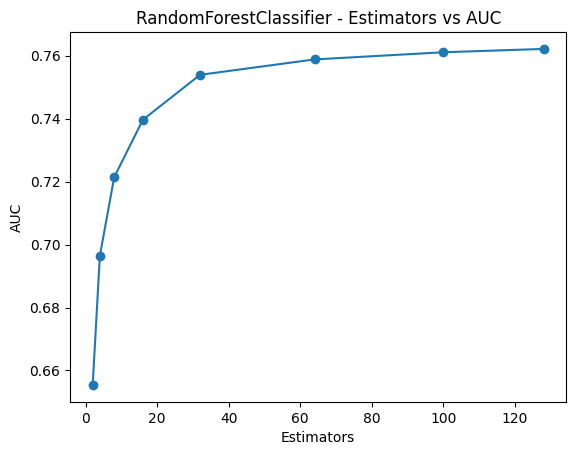

In [84]:
kf = KFold(n_splits = 5, shuffle = True, random_state=SEED)
l_estimators = [2, 4, 8, 16, 32, 64, 100, 128]

total_scores = []
for estimator in l_estimators:
  fold_accuracy = []
  base_rf = RandomForestClassifier(n_estimators = estimator, random_state = SEED)
  for train_fold, test_fold in kf.split(x_train_ml):

    # Division train test aleatoria
    f_train = x_train_ml.iloc[train_fold]
    f_test = x_train_ml.iloc[test_fold]

    # Entrenamiento y ejecucion del modelo
    base_rf.fit(X = f_train.drop(columns=[TARGET]), y = f_train[TARGET])
    #y_pred = base_rf.predict(X = f_test.drop(columns=['ES_NOPAGO']))
    y_pred_proba = base_rf.predict_proba(X = f_test.drop(columns=[TARGET]))[:,1]

    # Evaluacion del modelo
    #accuracy = accuracy_score(f_test['ES_NOPAGO'], y_pred)
    auc = roc_auc_score(f_test[TARGET], y_pred_proba)
    fold_accuracy.append(auc)
  total_scores.append(sum(fold_accuracy) / len(fold_accuracy))

print(total_scores)
plt.plot(l_estimators, total_scores, marker = 'o')
plt.title('RandomForestClassifier - Estimators vs AUC')
plt.ylabel('AUC')
plt.xlabel('Estimators')
plt.show()

* Se realizó una validación cruzada de 5-FOLD probando distintas cantidades de estimadores.  
  El resultado muestra que el número óptimo de árboles esta entre **64 y 100**, ya que a partir de este punto el AUC se estabiliza y no mejora significativamente.  
  Por lo tanto, aumentar más estimadores no es conveniente porque puede incrementar el tiempo de cómputo y generar sobreajuste.  

* Adicionalmente, se utilizó la métrica **AUC**, porque es más robusta que la exactitud al evaluar modelos desbalanceados, en nuestro caso posee un leve desbalanceo.  
  El AUC mide la capacidad de discriminación entre clases (pago vs. no pago), lo que es clave en este tipo de problema.


#### Encontrando la profundidad mas optima

[0.7573605943209132, 0.7604239997735466, 0.768023249019825, 0.7729337935077097, 0.7764588276171279, 0.7788988708921801, 0.7807484636304893, 0.7808010873278117, 0.7809872158646091, 0.7799662348263038, 0.7789913867371311, 0.7780855781217426, 0.7768697005437328, 0.7736840945081956, 0.7735206747312222, 0.7705346007785637, 0.7684137480743148, 0.7674897264654146, 0.7647511762854914]


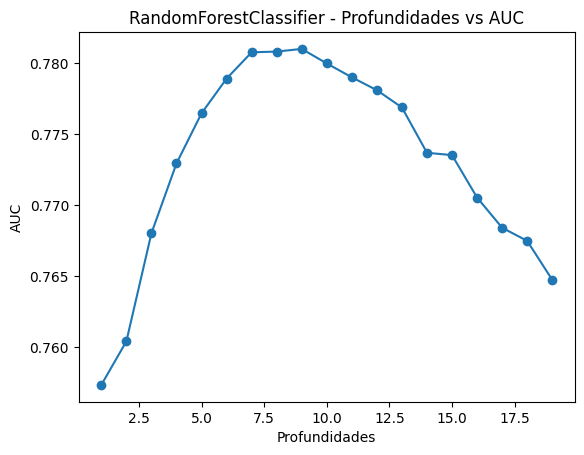

In [85]:
kf = KFold(n_splits = 5, shuffle = True, random_state=SEED)
l_profundidades = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]

total_scores = []
for profundidad in l_profundidades:
  fold_accuracy = []
  base_rf = RandomForestClassifier(n_estimators = 64, random_state = SEED, max_depth = profundidad)
  for train_fold, test_fold in kf.split(x_train_ml):
    # Division train test aleatoria
    f_train = x_train_ml.iloc[train_fold]
    f_test = x_train_ml.iloc[test_fold]

    # Entrenamiento y ejecucion del modelo
    base_rf.fit(X = f_train.drop(columns=[TARGET]), y = f_train[TARGET])
    #y_pred = base_rf.predict(X = f_test.drop(columns=['ES_NOPAGO']))
    y_pred_proba = base_rf.predict_proba(X = f_test.drop(columns=[TARGET]))[:,1]

    # Evaluacion del modelo
    #accuracy = accuracy_score(f_test['ES_NOPAGO'], y_pred)
    auc = roc_auc_score(f_test[TARGET], y_pred_proba)
    fold_accuracy.append(auc)
  total_scores.append(sum(fold_accuracy) / len(fold_accuracy))

print(total_scores)
plt.plot(l_profundidades, total_scores, marker = 'o')
plt.title('RandomForestClassifier - Profundidades vs AUC')
plt.ylabel('AUC')
plt.xlabel('Profundidades')
plt.show()

- Uno de los hiperparámetros más relevantes en un **Random Forest** es la **profundidad máxima de los árboles (max_depth)**, ya que controla el equilibrio entre sesgo y varianza.  
- Mediante **validación cruzada** se evaluaron distintas profundidades, tomando como referencia el mejor número de estimadores (64).  
- El resultado óptimo se obtuvo en un rango de **8 a 10 niveles de profundidad** sin embargo el mejor Score se obute con una profundidad de **8 niveles** luego de eso se ve que baja un poco su rendimiento.
- Se hara una optimización con RandomSearchCV probando estos niveles de profundidad, no es tan ideal darle un nivel de 8, existe una probabilidad de que se sobreajuste.


#### Optimización  - RandomizedSearchCV

In [86]:

## ==> RandomizedSearchCV Random Forest
rf = RandomForestClassifier(
    random_state=SEED,
    class_weight='balanced'
)

params_rf = {
    "n_estimators": [64, 128, 512],
    "max_depth": [4, 6, 8, 10],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", 0.3, 0.5]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_rf,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1
)

rf_random.fit(x_train, y_train)
print(rf_random.best_params_)
rf_random.best_estimator_

{'max_depth': 8, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 512}


RandomForestClassifier(class_weight='balanced', max_depth=8, max_features=0.3,
                       min_samples_leaf=4, min_samples_split=8,
                       n_estimators=512, random_state=876)

In [87]:
best_rf_random = rf_random.best_estimator_

In [73]:
# import joblib

# # Cargar el modelo
# #best_rf_random = joblib.load('models/modelo_rf.pkl')
# best_rf_random = joblib.load('../models/best_modelo_rf.pkl')

# best_rf_random

#### Predicciones

In [64]:
y_proba = best_rf_random.predict_proba(x_test)[:,1]
y_predict = best_rf_random.predict(x_test)

x_proba = best_rf_random.predict_proba(x_train)[:,1]
x_predict = best_rf_random.predict(x_train)

Aqui conseguimos las predicciones tanto de x_train (para detectar sobreajuste) y x_test

#### AUC - SCORE

In [65]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}') # 0.7853

roc_auc_score  (conjunto de test):  0.7853


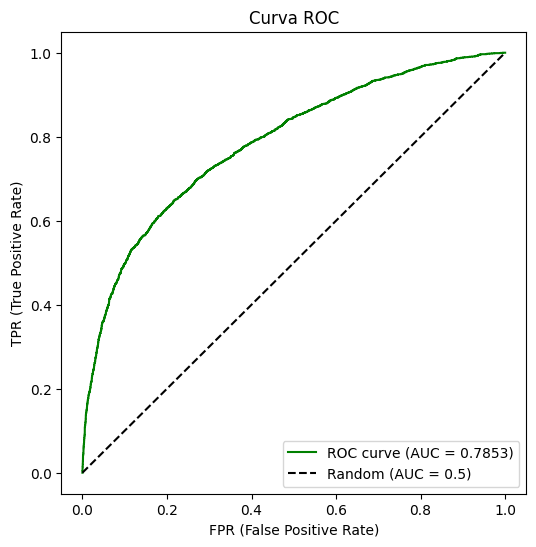

In [66]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

#### Verificando si existe Overfiting


In [67]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  0.8471


In [92]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_rf_random, x_train, y_train, cv = folds, scoring = 'roc_auc')
print(f"AUC por fold {scores}")
print(f"AUC promedio: {scores.mean():.4f}")

AUC por fold [0.77416139 0.77938268 0.79100315 0.79580519 0.77754423]
AUC promedio: 0.7836


#### Metricas de Bondad

In [68]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.7706
Precision: 0.4854
Recall: 0.6114
F1-score: 0.5412


In [69]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[5712 1289]
 [ 773 1216]]


In [70]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      7001
           1       0.49      0.61      0.54      1989

    accuracy                           0.77      8990
   macro avg       0.68      0.71      0.69      8990
weighted avg       0.79      0.77      0.78      8990



#### Metricas de Bondad con umbral de corte

In [71]:

umbrales = np.linspace(0, 1, 101)  

mejor_umbral = None
mejor_f1 = -1

for umbral in umbrales:
    y_pred = (y_proba >= umbral).astype(int)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if recall >= 0.7 and f1 > mejor_f1: 
        mejor_f1 = f1
        mejor_umbral = umbral

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"F1: {mejor_f1:.4f}")
print(f"Recall: {recall_score(y_test, (y_proba >= mejor_umbral).astype(int)):.4f}")

Mejor umbral: 0.4100
F1: 0.5213
Recall: 0.7109


In [72]:
y_pred_opt = (y_proba >= mejor_umbral).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )


Accuracy: 0.7111
Precision: 0.4115
Recall: 0.7109
F1-score: 0.5213


In [98]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[4979 2022]
 [ 575 1414]]


In [99]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      7001
           1       0.41      0.71      0.52      1989

    accuracy                           0.71      8990
   macro avg       0.65      0.71      0.66      8990
weighted avg       0.79      0.71      0.73      8990



#### Variables mas importantes del modelo

In [183]:
importance = best_rf_random.feature_importances_
feat_importances = pd.DataFrame({
    'feature' : X.columns,
    'importance' : importance
}).sort_values(by='importance', ascending=False)

In [186]:
feat_importances.head(10)

,feature,importance
24,MESES_AL_DIA,0.136902
3,PAY_1,0.129773
23,DEMORA_MAX,0.124792
22,DEMORA_SUM,0.123666
21,CREDIT_UTIL1,0.045957
4,PAY_2,0.043952
9,BILL_AMT1,0.028134
0,LIMIT_BAL,0.028103
17,PAY_AMT3,0.028098
15,PAY_AMT1,0.027453


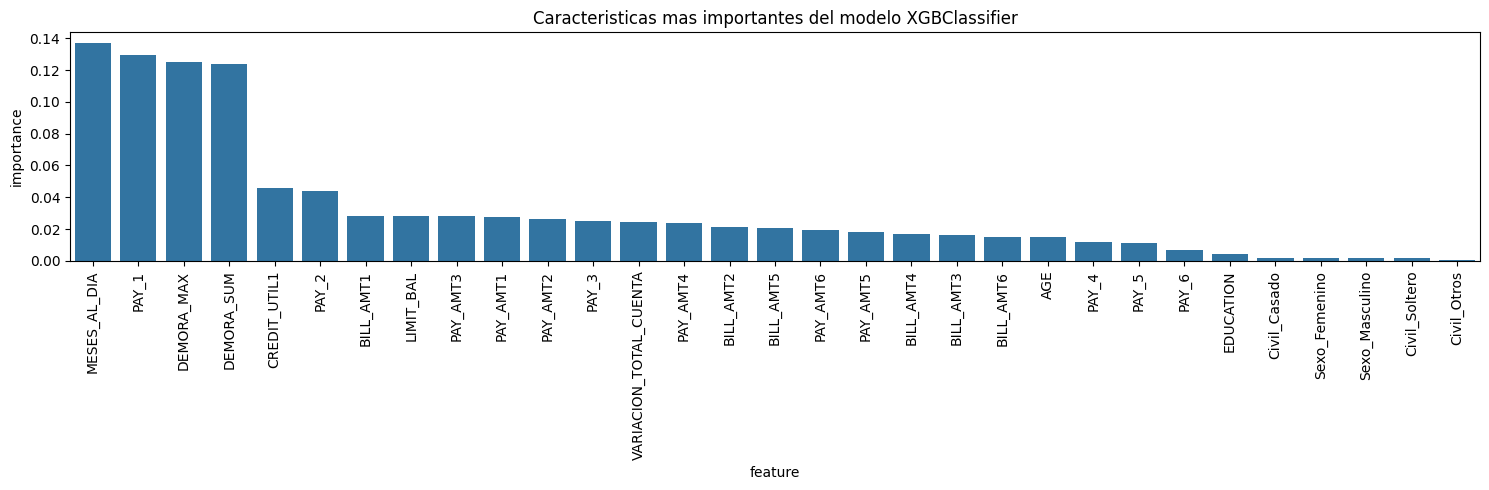

In [101]:
plt.figure(figsize=(15,5))
sns.barplot(
    data = feat_importances,
    x = 'feature',
    y = 'importance'
)
plt.xticks(rotation=90)
plt.title('Caracteristicas mas importantes del modelo XGBClassifier')
plt.tight_layout()
plt.show()

Las 5 variables más relevantes para el modelo XGBClassifier son **MESES_AL_DIA**, **PAY_1**, **DEMORA_MAX**, **DEMORA_SUM**, **CREDIT_UTIL**.  

Además, aparecen con menor peso las variables derivadas del **MARRIAGE** (Civil_Casado, Civil_Soltero, Civil_Otros) y del **SEXO** (Sexo_Masculino, Sexo_Femenino), confirmando que la codificación One-Hot permitió incluir estas categorías sin pérdida de información.  

Esto demuestra que la **ingeniería de características** y la **codificación adecuada de variables categóricas** enriquecieron el modelo al capturar mejor los factores asociados al riesgo de impago.



#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                       |
|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | RandomForestClassifier                                                                                                                                            |
| **Justificación**                         | Algoritmo robusto, no requiere supuestos de normalidad, maneja outliers, no es sensible a la multicolinealidad y captura relaciones no lineales.                  |
| **Ventajas**                              | Buen rendimiento en clasificación binaria, balance entre sesgo y varianza, interpretabilidad mediante importancia de variables.                                   |
| **Hiperparámetros principales**           | **n_estimators = 512**, **max_depth = 8**, **max_features = 0.3**, **min_samples_leaf = 4**, **min_samples_split = 8**, **class_weight = balanced**. Estos parámetros mejoraron la estabilidad y redujeron el sesgo. |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.7836** (muy cercano al test con **0.7853** y train **0.8471**), lo que confirma un modelo generalizable y sin sobreajuste.|
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.7706**, Precision: **0.4854**, Recall: **0.6114**, F1-score: **0.5412**. Buen balance inicial entre precisión y sensibilidad.                       |
| **Métricas con umbral corte (0.41)**      | F1: **0.5213**, Recall: **0.7109**. Ajuste mejora Recall (detectar morosos) a costa de una leve caída en precisión.                                              |
| **Interpretación del umbral**             | En riesgo crediticio es más costoso no detectar morosos (falsos negativos). Por eso se prioriza **Recall** sobre **Precision**, justificando el uso del umbral.   |
| **Variables más importantes**             | **MESES_AL_DIA, PAY_1, DEMORA_MAX, DEMORA_SUM, CREDIT_UTIL**. Estas variables reflejan capacidad de pago, historial y riesgo de sobreuso.                        |
| **Conclusión**                            | El modelo logra un equilibrio sólido entre Recall y Precision, siendo útil para la detección temprana de clientes con riesgo de no pago.                         |

### Guardando modelo en MLflow

In [177]:
'''
Para ejecutar visualizar el modelo en la UI de MLflow
mlflow ui --backend-store-uri "file:///C:/Users/Dell/Documents/MASTER UNIVERSITARIO/TRABAJO FINAL 2/Desarrollo TFM/Desarrollo TC Default/notebooks/mlruns"
'''
## ==> Configuracion MLflow — debe ir ANTES del registro
import mlflow
import mlflow.sklearn
import joblib
import os
import shutil


BASE_DIR = os.getcwd()
MLRUNS_DIR = os.path.join(BASE_DIR, "mlruns")

if os.path.exists(MLRUNS_DIR):
    shutil.rmtree(MLRUNS_DIR)

os.makedirs(os.path.join(MLRUNS_DIR, ".trash"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)

mlflow.set_tracking_uri(f"file:///{MLRUNS_DIR}".replace("\\", "/"))
mlflow.set_experiment("no-pago-tc-experimentos")

## ==> Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

## ==> Registro Random Forest en MLflow
with mlflow.start_run(run_name="RandomForest"):
    
    # 1 — Parámetros
    mlflow.log_params({
        "model": "RandomForestClassifier",
        "n_estimators": 512,
        "max_depth": 8,
        "max_features": 0.3,
        "min_samples_leaf": 4,
        "min_samples_split": 8,
        "class_weight": "balanced",
        "umbral_corte": 0.41
    })
    
    # 2 — Métricas sin umbral
    mlflow.log_metrics({
       # "auc_cv": 0.7836,
        "auc_test": 0.7853,
       # "auc_train": 0.8471,
        "accuracy_sin_umbral": 0.7706,
        "precision_sin_umbral": 0.4854,
        "recall_sin_umbral": 0.6114,
        "f1_sin_umbral": 0.5412
    })
    
    # 3 — Métricas con umbral
    mlflow.log_metrics({
        "accuracy_con_umbral": 0.7111,
        "precision_con_umbral": 0.4115,
        "recall_con_umbral": 0.7109,
        "f1_con_umbral": 0.5213
    })
    
    # 4 — Modelo como artefacto
    mlflow.sklearn.log_model(best_rf_random, "random_forest_model")
    
    # 5 — Modelo local en .pkl
    joblib.dump(best_rf_random, "models/modelo_rf.pkl")
    mlflow.log_artifact("models/modelo_rf.pkl")
    
    print("Random Forest registrado en MLflow exitosamente")

2026/04/26 07:48:35 INFO mlflow.tracking.fluent: Experiment with name 'no-pago-tc-experimentos' does not exist. Creating a new experiment.


Random Forest registrado en MLflow exitosamente


## KNN (KNeighborsClassifier)

In [110]:
#df_ml_knn = df_feature.copy()
df_ml_knn = df_feature_dummies.copy()
df_ml_knn.drop(columns=['BILL_AMT2', 'BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6' ], inplace=True) ##==> Caracteristicas eliminadas por la alta correlacion
df_ml_knn.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,20000.0,2,24,2,2,-1,-1,-2,-2,3913.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0.195650,4,2,4,3913.0,1,0,0,0,1
1,120000.0,2,26,-1,2,0,0,0,2,2682.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.022350,4,2,4,957.0,0,1,0,0,1
2,90000.0,2,34,0,0,0,0,0,0,29239.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.324878,0,0,6,15680.0,0,1,0,0,1
3,50000.0,2,37,0,0,0,0,0,0,46990.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.939800,0,0,6,18676.0,1,0,0,0,1
4,50000.0,2,57,-1,0,-1,0,0,0,8617.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.172340,0,0,6,2947.0,1,0,0,1,0


Aqui eliminamos las variables con multicolinealidad, ya que KNN es sensible a estos

#### Normalizacion

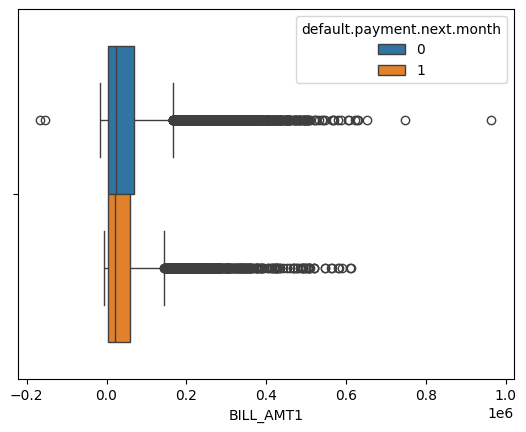

In [111]:
sns.boxplot(
    data=df_ml_knn,
    x='BILL_AMT1',
    hue='default.payment.next.month'
)
plt.show()

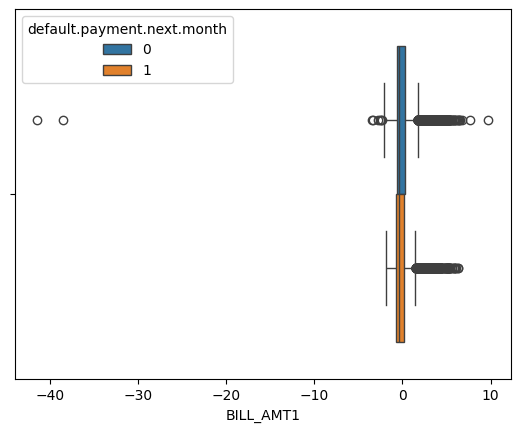

In [112]:
cols_logs = ['LIMIT_BAL', 'BILL_AMT1', 
             'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
             'CREDIT_UTIL1', 'VARIACION_TOTAL_CUENTA']

# 1) Transformacion Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
df_ml_knn[cols_logs] = pt.fit_transform(df_ml_knn[cols_logs])

# 2) Visualizacion
sns.boxplot(
    data=df_ml_knn,
    x='BILL_AMT1',
    hue='default.payment.next.month'
)
plt.show()

Aplicamos la transformación **Yeo-Johnson** para suavizar la distribución de las variables numéricas.  
Esto es necesario porque el modelo **KNN** se basa en distancias (Euclídeas, Manhattan, etc.), y si no se corrigen escalas o distribuciones, una variable con valores grandes (ej. `BILL_AMT1` con 20,000) podría dominar sobre otras como `AGE` (máximo ~80).  
De esta forma, reducimos la asimetría y mejoramos la comparabilidad entre variables.


In [113]:
# 3) Estandarizacion
sc = StandardScaler()
df_ml_knn[cols_logs + ['AGE']] = sc.fit_transform(df_ml_knn[cols_logs + ['AGE']])
df_ml_knn

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,-1.664977,2,-1.246078,2,2,-1,-1,-2,-2,-0.655612,-1.727316,-0.350472,-1.632406,-1.580260,-1.559086,-1.517798,1,-0.409726,4,2,4,0.279397,1,0,0,0,1
1,-0.089745,2,-1.029141,-1,2,0,0,0,2,-0.680121,-1.727316,-0.205198,-0.082417,0.006925,-1.559086,0.330229,1,-1.082056,4,2,4,-0.106784,0,1,0,0,1
2,-0.396050,2,-0.161397,0,0,0,0,0,0,-0.240301,-0.066818,-0.033970,-0.082417,0.006925,0.016652,0.740265,0,-0.011426,0,0,6,0.720038,0,1,0,0,1
3,-0.953291,2,0.164007,0,0,0,0,0,0,0.016303,0.061381,0.100830,-0.008417,0.044670,0.042763,0.057031,0,1.218783,0,0,6,0.780217,1,0,0,0,1
4,-0.953291,2,2.333368,-1,0,-1,0,0,0,-0.569266,0.061381,1.949655,1.066002,1.056731,-0.123725,-0.083050,0,-0.489833,0,0,6,0.196999,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.638033,3,0.380943,0,0,0,0,0,0,1.801795,0.875015,1.467854,0.667286,0.489558,0.738230,0.057031,0,1.098640,0,0,6,1.650561,1,0,0,1,0
29996,0.164586,3,0.814815,-1,-1,-1,-1,0,0,-0.701126,0.021039,0.376936,1.001833,-0.669551,-1.559086,-1.517798,0,-1.132187,0,0,6,0.041209,0,1,0,1,0
29997,-1.371401,2,0.164007,4,3,2,-1,0,0,-0.662422,-1.727316,-1.708162,1.587396,0.646709,0.303113,0.518990,1,-0.684884,9,4,3,-0.149774,0,1,0,1,0
29998,-0.514826,3,0.597879,1,-1,0,0,0,-1,-0.963958,2.840091,0.359318,-0.016043,0.279535,2.231962,0.287665,1,-1.280871,1,1,5,-1.354943,1,0,0,1,0


Posteriormente realizamos la **estandarización (z-score)**, ya que KNN es sensible a la escala de los datos.  
Esto asegura que todas las variables tengan media 0 y desviación estándar 1, evitando que atributos con unidades grandes distorsionen las distancias.  
Además, la estandarización es un requisito clave antes de aplicar **PCA**, garantizando que cada variable aporte de forma equilibrada a la varianza total.


#### PCA

Varizana explicada con 1, es de : 0.355279567192992
Varizana explicada con 2, es de : 0.5056779227996495
Varizana explicada con 3, es de : 0.6051287115219629
Varizana explicada con 4, es de : 0.6868381754691901
Varizana explicada con 5, es de : 0.7476526700891802
Varizana explicada con 6, es de : 0.8017658141086272
Varizana explicada con 7, es de : 0.8519243381717693


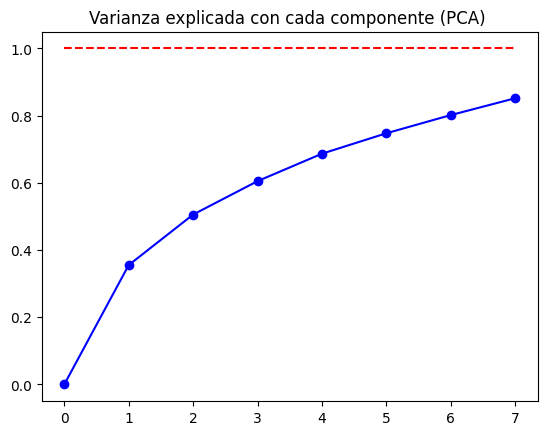

In [114]:
## ==> PCA
expl_var = [0]

for n_components in [1, 2, 3, 4, 5, 6, 7]:
    var_pca = PCA(n_components=n_components)
    X_pca_n = var_pca.fit_transform(df_ml_knn[cols_logs + ['AGE']])
    expl_var.append(sum(var_pca.explained_variance_ratio_))
    print(f'Varizana explicada con {n_components}, es de : {sum(var_pca.explained_variance_ratio_)}')
plt.plot([0, 1, 2, 3, 4, 5, 6, 7], expl_var, 'bo-')
plt.plot([0, 7], [1, 1], 'r--')
plt.title("Varianza explicada con cada componente (PCA) ")
plt.show()

Finalmente aplicamos **PCA** para reducir la dimensionalidad y optimizar el entrenamiento.  
Con **7 componentes principales** logramos capturar aproximadamente el **85% de la varianza total**, lo que nos permite trabajar con un dataset más compacto sin perder demasiada información.  
Esto ayuda a disminuir ruido, mejorar tiempos de cómputo y reducir la probabilidad de sobreajuste en el modelo.


In [117]:
pca_5 = PCA(n_components=7)
train_ml_knn_pca = pca_5.fit_transform(df_ml_knn[cols_logs + ['AGE']])
train_ml_knn_pca = pd.DataFrame(train_ml_knn_pca, columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7' ], index=df_ml_knn.index)

train_ml_knn_pca = pd.concat(
    [train_ml_knn_pca, df_ml_knn[['Civil_Casado','Civil_Soltero','Civil_Otros',#'MARRIAGE',
                                  'EDUCATION',
                                  
                                  'Sexo_Masculino','Sexo_Femenino',#'SEX',
                                   'PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
                                   'default.payment.next.month']]],
    axis=1
).reset_index(drop=True)
train_ml_knn_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Civil_Casado,Civil_Soltero,Civil_Otros,EDUCATION,Sexo_Masculino,Sexo_Femenino,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default.payment.next.month
0,3.530825,-1.630821,0.503440,-0.917495,0.189053,0.994294,0.059421,1,0,0,2,0,1,2,2,-1,-1,-2,-2,1
1,1.659810,0.428080,0.525937,-1.041360,-0.634810,1.128526,-0.023761,0,1,0,2,0,1,-1,2,0,0,0,2,1
2,-0.209575,-0.307431,0.153606,-0.143793,-0.263223,0.572926,0.116691,0,1,0,2,0,1,0,0,0,0,0,0,0
3,-0.394088,-1.509458,0.059997,0.503837,0.063674,0.379047,0.138700,1,0,0,2,0,1,0,0,0,0,0,0,0
4,-1.030621,0.618095,-0.567740,2.311278,1.135856,1.865949,0.378551,1,0,0,2,1,0,-1,0,-1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,-2.868100,-1.059645,-1.176169,-0.469777,0.595605,0.198093,0.100277,1,0,0,3,1,0,0,0,0,0,0,0,0
29961,1.266829,0.727319,-0.772346,0.125443,1.963490,0.371378,0.791512,0,1,0,3,1,0,-1,-1,-1,-1,0,0,0
29962,0.746046,0.121522,0.813290,0.893691,-1.631291,0.148214,1.695037,0,1,0,2,1,0,4,3,2,-1,0,0,1
29963,-1.086491,2.065121,1.425367,1.653225,1.151478,-1.008387,-0.228821,1,0,0,3,1,0,1,-1,0,0,0,-1,1


#### Encontrando la cantidad de vecinos y los weights mas optimos

Mejor k por AUC con weights="uniform": 19 | AUC=0.7565
Mejor k por AUC con weights="distance": 19 | AUC=0.7540


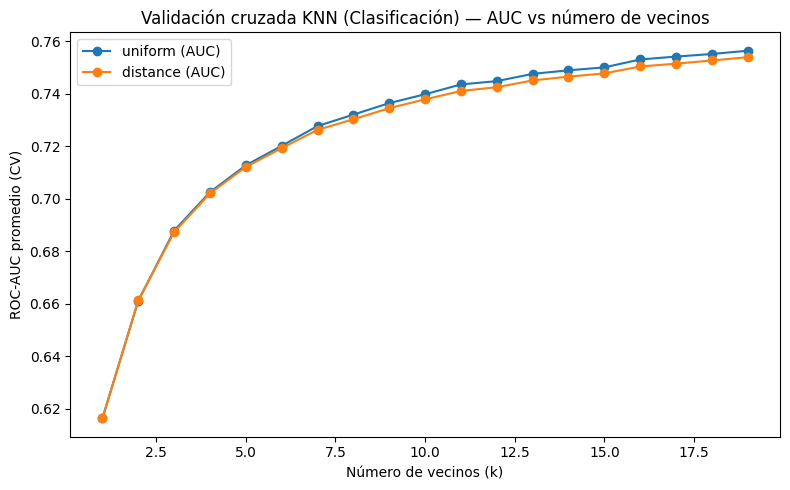

In [120]:
cv = KFold(n_splits = 5, shuffle = True, random_state=SEED)
ks = range(1, 20)

plt.figure(figsize=(8,5))

for weights in ['uniform', 'distance']:
    mean_auc = []
    #mean_f1  = []

    for n_neighbors in ks:
        fold_auc =  []

        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)

        for tr_idx, te_idx in cv.split(train_ml_knn_pca):
            f_train = train_ml_knn_pca.iloc[tr_idx]
            f_test  = train_ml_knn_pca.iloc[te_idx]
            # Entrenamiento y ejecucion del modelo
            knn.fit(
                X =  f_train.drop(columns=[TARGET], axis = 1),
                y =  f_train[TARGET]
            )
            y_proba = knn.predict_proba(
                X = f_test.drop(columns=[TARGET], axis = 1)
                )[:, 1]

            # Evaluacion del modelo
            fold_auc.append(roc_auc_score(f_test[TARGET], y_proba))
            #fold_f1.append(f1_score(f_test[TARGET], pred))

        mean_auc.append(np.mean(fold_auc))
        #mean_f1.append(np.mean(fold_f1))

    # Curva principal: AUC vs k
    plt.plot(ks, mean_auc, marker='o', label=f'{weights} (AUC)')
    # Reporte del mejor k por AUC
    best_k = ks[int(np.argmax(mean_auc))]
    print(f'Mejor k por AUC con weights="{weights}": {best_k} | AUC={max(mean_auc):.4f}')


plt.title('Validación cruzada KNN (Clasificación) — AUC vs número de vecinos')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('ROC-AUC promedio (CV)')
plt.legend()
plt.tight_layout()
plt.show()

Con validación cruzada se evaluó `k` y `weights`. El AUC se estabiliza cerca de **k≈16**; el esquema **`distance`** rinde marginalmente mejor que `uniform`.


In [121]:
X = train_ml_knn_pca.drop([TARGET], axis= 1)
y = train_ml_knn_pca[TARGET]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)

#### Optimizacion

In [122]:
knn = KNeighborsClassifier()

params_knn = {
    "n_neighbors" : [3, 5, 7, 9, 10],
    "weights" : ["uniform","distance"],
    "algorithm" : ["auto", "ball_tree", "kd_tree", "brute"],
    "leaf_size" : [10,20,30,40],
}
knn_rd = RandomizedSearchCV(
    estimator = knn,
    param_distributions=params_knn,
    n_iter = 50,
    cv = 5,
    random_state = SEED,
    n_jobs= -1,
    scoring = 'roc_auc'
)
knn_rd.fit(
    X = x_train,
    y = y_train
)

best_random_knn = knn_rd.best_estimator_
best_params_knn = knn_rd.best_params_

print(f'Best estimator : {best_random_knn}')
print(f'Best params : {best_params_knn}')

Best estimator : KNeighborsClassifier(algorithm='kd_tree', leaf_size=20, n_neighbors=10)
Best params : {'weights': 'uniform', 'n_neighbors': 10, 'leaf_size': 20, 'algorithm': 'kd_tree'}


In [123]:
y_proba = best_random_knn.predict_proba(x_test)[:,1]
y_predict = best_random_knn.predict(x_test)

x_proba = best_random_knn.predict_proba(x_train)[:,1]
x_predict = best_random_knn.predict(x_train)

#### AUC - SCORE

In [124]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}')

roc_auc_score  (conjunto de test):  0.74


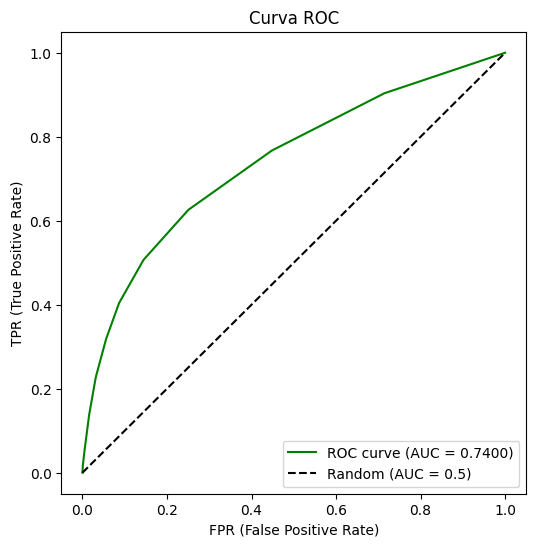

In [125]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

#### Verificando si existe Overfiting

In [126]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  0.8464


In [127]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_random_knn, x_train, y_train, cv = folds, scoring = 'roc_auc')
print(f"AUC por fold {scores}")
print(f"AUC promedio: {scores.mean():.4f}")

AUC por fold [0.73107553 0.73909838 0.75123387 0.75502314 0.73229875]
AUC promedio: 0.7417


#### Metricas de Bondad

In [128]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.8056
Precision: 0.6173
Recall: 0.3188
F1-score: 0.4204


In [129]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[6608  393]
 [1355  634]]


In [130]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88      7001
           1       0.62      0.32      0.42      1989

    accuracy                           0.81      8990
   macro avg       0.72      0.63      0.65      8990
weighted avg       0.78      0.81      0.78      8990



#### Metricas de Bondad con umbral de corte

In [131]:

umbrales = np.linspace(0, 1, 101)  

mejor_umbral = None
mejor_f1 = -1

for umbral in umbrales:
    y_pred = (y_proba >= umbral).astype(int)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if recall >= 0.7 and f1 > mejor_f1: 
        mejor_f1 = f1
        mejor_umbral = umbral

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"F1: {mejor_f1:.4f}")
print(f"Recall: {recall_score(y_test, (y_proba >= mejor_umbral).astype(int)):.4f}")

Mejor umbral: 0.1100
F1: 0.4587
Recall: 0.7672


In [132]:
y_pred_opt = (y_proba >= mejor_umbral).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )

Accuracy: 0.5993
Precision: 0.3271
Recall: 0.7672
F1-score: 0.4587


In [133]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[3862 3139]
 [ 463 1526]]


In [134]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.89      0.55      0.68      7001
           1       0.33      0.77      0.46      1989

    accuracy                           0.60      8990
   macro avg       0.61      0.66      0.57      8990
weighted avg       0.77      0.60      0.63      8990



#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                   |
|-------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | KNeighborsClassifier (KNN).                                                                                                                                    |
| **Justificación**                         | Algoritmo basado en la similitud de instancias. Útil cuando la relación entre variables y clase no es lineal. Sensible a escalas, por lo que requiere normalización. |
| **Ventajas**                              | Fácil de interpretar, no requiere entrenamiento explícito (lazy learning), se adapta bien a datasets de tamaño moderado.                                       |
| **Hiperparámetros más relevantes**        | `n_neighbors=10`, `weights='uniform'`, `leaf_size=20`, `algorithm='kd_tree'`. Optimización mediante **RandomizedSearchCV**.                                    |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.7417**, cercano al test con **0.74** y train **0.8464**, lo que confirma generalización aceptable sin sobreajuste severo. |
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.8056**, Precision: **0.6173**, Recall: **0.3188**, F1-score: **0.4204**. Recall bajo indica dificultad para detectar morosos sin ajuste de umbral. |
| **Métricas con umbral corte (0.11)**      | Accuracy: **0.5993**, Precision: **0.3271**, Recall: **0.7672**, F1-score: **0.4587**. Ajuste que mejora Recall (morosos) a costa de precisión y accuracy.      |
| **Interpretación del umbral**             | Ajustar el umbral es necesario porque KNN tiende a favorecer a la clase mayoritaria. Con 0.11 se prioriza Recall, clave en problemas de riesgo crediticio.     |
| **Normalización y PCA**                   | Se aplicó **Yeo-Johnson** + **Estandarización (z-score)** para evitar sesgos por escala. Con **7 componentes PCA** se capturó el **85% de la varianza total**. |
| **Conclusión**                            | El modelo KNN con ajuste de umbral mejora la detección de clientes en riesgo, aunque su AUC y F1 son inferiores a otros modelos, requiriendo más preprocesamiento. |


In [178]:
## ==> Registro KNN en MLflow
with mlflow.start_run(run_name="KNN"):
    
    # 1 — Parámetros
    mlflow.log_params({
        "model": "KNeighborsClassifier",
        "n_neighbors": 10,
        "weights": "uniform",
        "leaf_size": 20,
        "algorithm": "kd_tree",
        "umbral_corte": 0.11,
        "pca_components": 7,
        "varianza_capturada": 0.85
    })
    
    # 2 — Métricas sin umbral
    mlflow.log_metrics({
       # "auc_cv": 0.7417,
        "auc_test": 0.74,
       # "auc_train": 0.8464,
        "accuracy_sin_umbral": 0.8056,
        "precision_sin_umbral": 0.6173,
        "recall_sin_umbral": 0.3188,
        "f1_sin_umbral": 0.4204
    })
    
    # 3 — Métricas con umbral
    mlflow.log_metrics({
        "accuracy_con_umbral": 0.5993,
        "precision_con_umbral": 0.3271,
        "recall_con_umbral": 0.7672,
        "f1_con_umbral": 0.4587
    })
    
    # 4 — Modelo como artefacto
    mlflow.sklearn.log_model(best_random_knn, "knn_model")
    
    # 5 — Modelo local en .pkl
    joblib.dump(best_random_knn, "models/modelo_knn.pkl")
    mlflow.log_artifact("models/modelo_knn.pkl")
    
    print("KNN registrado en MLflow exitosamente")

KNN registrado en MLflow exitosamente


## LogisticRegression

#### Normalizacion

In [135]:
df_ml_logi = df_feature_dummies.copy()

In [136]:
# df_ml_logi = df_bi.copy()

##==> Caracteristicas eliminadas por la alta correlacion
df_ml_logi.drop(columns=['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'], inplace=True)

## ==> Transformacion logaritmica
cols_logs = ['LIMIT_BAL', 'BILL_AMT1',
             'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pt = PowerTransformer(method = 'yeo-johnson')
df_ml_logi[cols_logs] = pt.fit_transform(df_ml_logi[cols_logs])

## ==> Estandarizacion
sc = StandardScaler()
df_ml_logi[cols_logs + ['AGE']] = sc.fit_transform(df_ml_logi[cols_logs + ['AGE']])

df_ml_logi.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,CREDIT_UTIL1,DEMORA_SUM,DEMORA_MAX,MESES_AL_DIA,VARIACION_TOTAL_CUENTA,Civil_Casado,Civil_Soltero,Civil_Otros,Sexo_Masculino,Sexo_Femenino
0,-1.664977,2,-1.246078,2,2,-1,-1,-2,-2,-0.655612,-1.727316,-0.350472,-1.632406,-1.580260,-1.559086,-1.517798,1,0.195650,4,2,4,3913.0,1,0,0,0,1
1,-0.089745,2,-1.029141,-1,2,0,0,0,2,-0.680121,-1.727316,-0.205198,-0.082417,0.006925,-1.559086,0.330229,1,0.022350,4,2,4,957.0,0,1,0,0,1
2,-0.396050,2,-0.161397,0,0,0,0,0,0,-0.240301,-0.066818,-0.033970,-0.082417,0.006925,0.016652,0.740265,0,0.324878,0,0,6,15680.0,0,1,0,0,1
3,-0.953291,2,0.164007,0,0,0,0,0,0,0.016303,0.061381,0.100830,-0.008417,0.044670,0.042763,0.057031,0,0.939800,0,0,6,18676.0,1,0,0,0,1
4,-0.953291,2,2.333368,-1,0,-1,0,0,0,-0.569266,0.061381,1.949655,1.066002,1.056731,-0.123725,-0.083050,0,0.172340,0,0,6,2947.0,1,0,0,1,0


#### Get Dummies

#### Encontrando los Hiperparametros de regularizacion

Mejor C para penalty="l1": 1.52 | AUC=0.7662
Mejor C para penalty="l2": 0.001 | AUC=0.7655


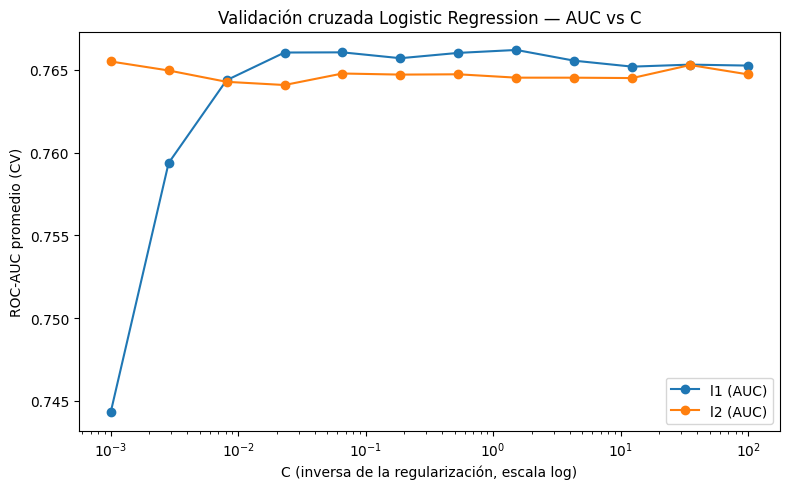

In [139]:
cv = KFold(n_splits = 5, shuffle = True, random_state=SEED)

cs = np.logspace(-3, 2, 12)
penalties = ['l1', 'l2']

plt.figure(figsize=(8,5))

for pen in penalties:
    mean_auc = []

    for C in cs:
        fold_auc =  []

        clf = LogisticRegression(
            penalty = pen,
            C=C,
            solver = 'liblinear',
            max_iter = 2000,
            random_state = SEED,
            class_weight = 'balanced'
        )

        for tr_idx, te_idx in cv.split(df_ml_logi):
            f_train = df_ml_logi.iloc[tr_idx]
            f_test  = df_ml_logi.iloc[te_idx]
            # Entrenamiento y ejecucion del modelo
            clf.fit(
                f_train.drop(columns=[TARGET], axis = 1),
                f_train[TARGET]
            )
            y_proba = clf.predict_proba(
                X = f_test.drop(columns=[TARGET], axis = 1)
                )[:, 1]

            # Evaluacion del modelo
            fold_auc.append(roc_auc_score(f_test[TARGET], y_proba))

        mean_auc.append(np.mean(fold_auc))

    # Curva principal: AUC vs k
    plt.semilogx(cs, mean_auc, marker='o', label=f'{pen} (AUC)')

    # Reporte del mejor k por AUC
    best_idx = int(np.argmax(mean_auc))
    print(f'Mejor C para penalty="{pen}": {cs[best_idx]:.4g} | AUC={mean_auc[best_idx]:.4f}')

plt.title('Validación cruzada Logistic Regression — AUC vs C')
plt.xlabel('C (inversa de la regularización, escala log)')
plt.ylabel('ROC-AUC promedio (CV)')
plt.legend()
plt.tight_layout()
plt.show()

Se probó con diferentes solvers, penalizaciones y valores de C.  
El mejor resultado se obtuvo con `penalty=l2`, `solver=sag` y `C=0.0129`.

In [140]:
X = df_ml_logi.drop([TARGET], axis= 1)
y = df_ml_logi[TARGET]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)

#### Optimizacion

In [141]:
logit = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)

param_logit = [
    # liblinear: soporta L1 y L2
    {"solver": ["liblinear"],
     "penalty": ["l1", "l2"],
     "C": loguniform(1e-3, 1e2)},

    # lbfgs / newton-cg / sag: solo L2
    {"solver": ["lbfgs", "newton-cg", "sag"],
     "penalty": ["l2"],
     "C": loguniform(1e-3, 1e2)},

    # saga: L1, L2 y elasticnet (único que soporta elasticnet)
    {"solver": ["saga"],
     "penalty": ["l1", "l2", "elasticnet"],
     "l1_ratio": uniform(0, 1),
     "C": loguniform(1e-3, 1e2)}
]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

logit_rd = RandomizedSearchCV(
    estimator=logit,
    param_distributions=param_logit,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

logit_rd.fit(x_train, y_train)

print("Best estimator:", logit_rd.best_estimator_)
print("Best params:", logit_rd.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best estimator: LogisticRegression(C=0.002880355188589453, class_weight='balanced',
                   max_iter=2000, random_state=876)
Best params: {'C': 0.002880355188589453, 'penalty': 'l2', 'solver': 'lbfgs'}


In [142]:
best_random_logi = logit_rd.best_estimator_
best_params_logi = logit_rd.best_params_

print(f'Best estimator : {best_random_logi}')
print(f'Best params : {best_random_logi}')

Best estimator : LogisticRegression(C=0.002880355188589453, class_weight='balanced',
                   max_iter=2000, random_state=876)
Best params : LogisticRegression(C=0.002880355188589453, class_weight='balanced',
                   max_iter=2000, random_state=876)


#### Predicciones

In [143]:
y_proba = best_random_logi.predict_proba(x_test)[:,1]
y_predict = best_random_logi.predict(x_test)

x_proba = best_random_logi.predict_proba(x_train)[:,1]
x_predict = best_random_logi.predict(x_train)

#### AUC - SOCRE

In [144]:
print(f'roc_auc_score  (conjunto de test):  {roc_auc_score(y_test, y_proba):.4}')

roc_auc_score  (conjunto de test):  0.7671


El modelo alcanzó un AUC de 0.8194 en el conjunto de test.  
La curva ROC confirma una buena separación frente al azar (AUC=0.5).

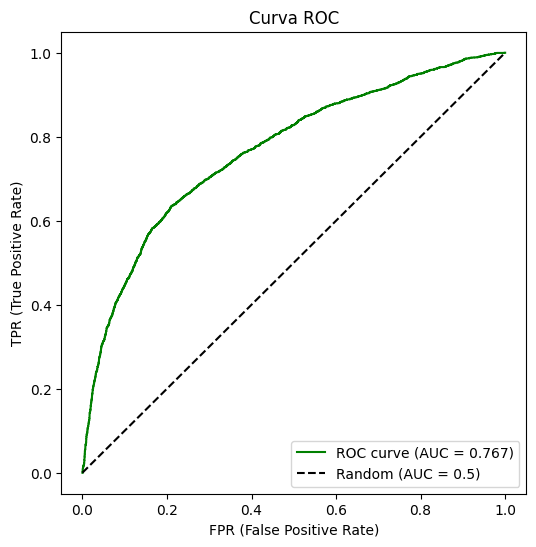

In [145]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = 'green', label = f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], color = 'black', linestyle = '--', label = 'Random (AUC = 0.5)')
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


#### Verificando si existe Overfiting

In [146]:
## ==> Check List Rapido
print(f'roc_auc_score  (conjunto de train):  {roc_auc_score(y_train, x_proba):.4}')

roc_auc_score  (conjunto de train):  0.7683


In [147]:
## ==> Validacion cruzada con los hiperparametros obtenido
folds = KFold(n_splits = 5, shuffle = True, random_state = SEED)
scores = cross_val_score(best_random_knn, x_train, y_train, cv = folds, scoring = 'roc_auc')
print("AUC por fold", scores)
print(f"AUC promedio {scores.mean():.4}" )

AUC por fold [0.6518948  0.6283678  0.65304741 0.65954407 0.65269189]
AUC promedio 0.6491


En validación cruzada (5 folds) se obtuvo un AUC promedio de 0.9135
con una desviación estándar baja (0.0055), lo que muestra estabilidad.

#### Metricas de Bondad

In [148]:
## ==> Sin establecer UMBRAL DE CORTE
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}" )
print(f"Precision: {precision_score(y_test, y_predict):.4f}" )
print(f"Recall: {recall_score(y_test, y_predict):.4f}" )
print(f"F1-score: {f1_score(y_test, y_predict):.4f}" )

Accuracy: 0.7485
Precision: 0.4517
Recall: 0.6395
F1-score: 0.5294


In [149]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predict))

Confusion matrix:
 [[5457 1544]
 [ 717 1272]]


In [150]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      7001
           1       0.45      0.64      0.53      1989

    accuracy                           0.75      8990
   macro avg       0.67      0.71      0.68      8990
weighted avg       0.79      0.75      0.76      8990



#### Metricas de Bondad con umbral de corte

In [151]:

umbrales = np.linspace(0, 1, 101)  

mejor_umbral = None
mejor_f1 = -1

for umbral in umbrales:
    y_pred = (y_proba >= umbral).astype(int)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if recall >= 0.7 and f1 > mejor_f1: 
        mejor_f1 = f1
        mejor_umbral = umbral

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"F1: {mejor_f1:.4f}")
print(f"Recall: {recall_score(y_test, (y_proba >= mejor_umbral).astype(int)):.4f}")

Mejor umbral: 0.4200
F1: 0.5081
Recall: 0.7059


In [152]:
y_pred_opt = (y_proba >= mejor_umbral).astype(int)

## ==> Metricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}" )
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}" )
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}" )
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}" )

Accuracy: 0.6976
Precision: 0.3968
Recall: 0.7059
F1-score: 0.5081


In [153]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_opt))

Confusion matrix:
 [[4867 2134]
 [ 585 1404]]


In [154]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78      7001
           1       0.40      0.71      0.51      1989

    accuracy                           0.70      8990
   macro avg       0.64      0.70      0.64      8990
weighted avg       0.78      0.70      0.72      8990



#### Variables mas importantes del modelo

In [155]:
coef = best_random_logi.coef_[0]
feat_importances = pd.DataFrame({
    'feature' : X.columns,
    'coefficient' : coef,
    'abs_importance' : abs(coef)
}).sort_values(by='abs_importance', ascending=False)
feat_importances

,feature,coefficient,abs_importance
18,DEMORA_MAX,2.385072e-01,2.385072e-01
3,PAY_1,2.074203e-01,2.074203e-01
0,LIMIT_BAL,-1.831001e-01,1.831001e-01
9,BILL_AMT1,1.229871e-01,1.229871e-01
19,MESES_AL_DIA,-1.219619e-01,1.219619e-01
17,DEMORA_SUM,1.167331e-01,1.167331e-01
16,CREDIT_UTIL1,1.118270e-01,1.118270e-01
10,PAY_AMT1,-1.055054e-01,1.055054e-01
21,Civil_Casado,8.734315e-02,8.734315e-02
11,PAY_AMT2,-8.449882e-02,8.449882e-02


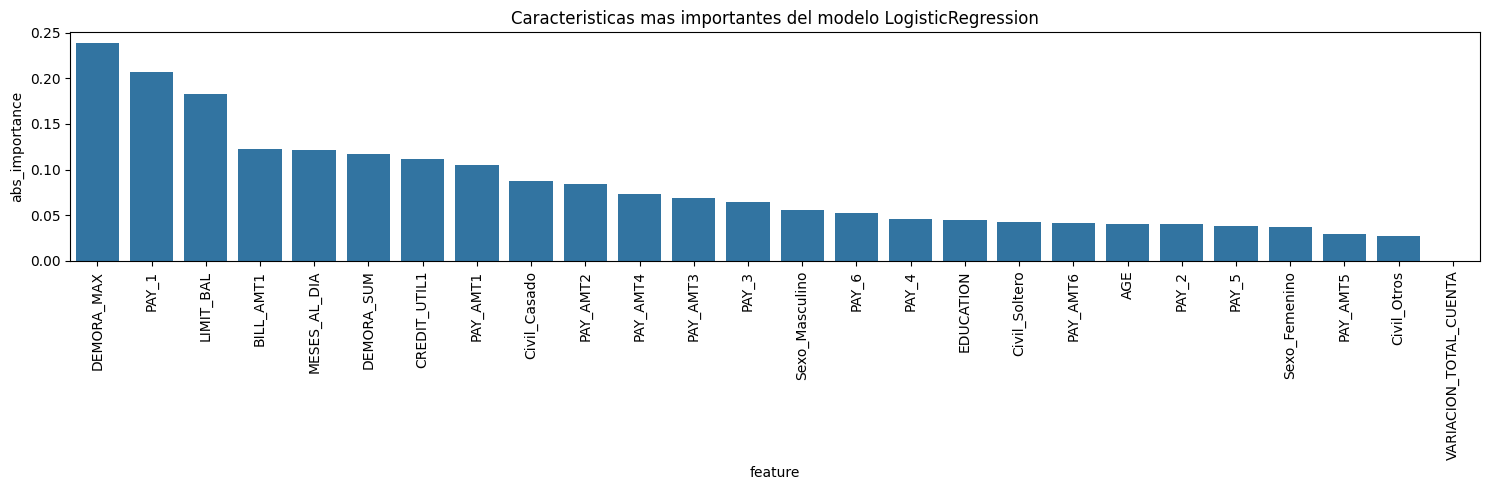

In [156]:
plt.figure(figsize=(15,5))
sns.barplot(
    data = feat_importances,
    x = 'feature',
    y = 'abs_importance'
)
plt.xticks(rotation=90)
plt.title('Caracteristicas mas importantes del modelo LogisticRegression')
plt.tight_layout()
plt.show()

#### Resumen
| Aspecto                                   | Descripción                                                                                                                                                       |
|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Modelo**                                | Logistic Regression (con `RandomizedSearchCV`).                                                                                                                   |
| **Justificación**                         | Modelo lineal base en clasificación. Robusto y eficiente en datasets medianos, permite interpretar directamente la contribución de cada variable mediante coeficientes. |
| **Ventajas**                              | Alta interpretabilidad, rápido de entrenar, menos propenso al sobreajuste que modelos más complejos.                                                               |
| **Hiperparámetros principales**           | **C = 0.00288**, **penalty = L2**, **solver = lbfgs**, **max_iter = 2000**, **class_weight = balanced**. Ajustes que estabilizan el modelo en presencia de clases desbalanceadas. |
| **Métrica principal (AUC)**               | AUC promedio en validación cruzada: **0.6491**. En test: **0.7671**, train: **0.7683**. Desempeño moderado, inferior a Random Forest y KNN.                       |
| **Métricas de bondad (sin umbral corte)** | Accuracy: **0.7485**, Precision: **0.4517**, Recall: **0.6395**, F1-score: **0.5294**. Recall decente pero con precisión limitada.                                 |
| **Métricas con umbral corte (0.42)**      | Accuracy: **0.6976**, Precision: **0.3968**, Recall: **0.7059**, F1-score: **0.5081**. Ajuste que aumenta recall sacrificando precisión, trade-off esperado en riesgo crediticio. |
| **Interpretación del umbral**             | Se prioriza el **Recall** (detectar morosos), aunque el modelo sacrifica precisión. Esto es aceptable en riesgo crediticio donde los falsos negativos son más costosos. |
| **Variables más importantes**             | **DEMORA_MAX, PAY_1, LIMIT_BAL, BILL_AMT1, MESES_AL_DIA, DEMORA_SUM, CREDIT_UTIL1**. Estas variables tienen mayor peso en la predicción, confirmando el impacto del historial y la capacidad de pago. |
| **Conclusión**                            | Logistic Regression ofrece un baseline interpretable y razonablemente estable. Aunque su AUC es menor que Random Forest y KNN, permite entender mejor los factores asociados al riesgo. |


In [179]:
## ==> Registro Logistic Regression en MLflow
with mlflow.start_run(run_name="LogisticRegression"):
    
    # 1 — Parámetros
    mlflow.log_params({
        "model": "LogisticRegression",
        "C": 0.00288,
        "penalty": "l2",
        "solver": "lbfgs",
        "max_iter": 2000,
        "class_weight": "balanced",
        "umbral_corte": 0.42
    })
    
    # 2 — Métricas sin umbral
    mlflow.log_metrics({
       # "auc_cv": 0.6491,
        "auc_test": 0.7671,
       # "auc_train": 0.7683,
        "accuracy_sin_umbral": 0.7485,
        "precision_sin_umbral": 0.4517,
        "recall_sin_umbral": 0.6395,
        "f1_sin_umbral": 0.5294
    })
    
    # 3 — Métricas con umbral
    mlflow.log_metrics({
        "accuracy_con_umbral": 0.6976,
        "precision_con_umbral": 0.3968,
        "recall_con_umbral": 0.7059,
        "f1_con_umbral": 0.5081
    })
    
    # 4 — Modelo como artefacto
    mlflow.sklearn.log_model(best_random_logi, "logistic_regression_model")
    
    # 5 — Modelo local en .pkl
    joblib.dump(best_random_logi, "models/modelo_logistic.pkl")
    mlflow.log_artifact("models/modelo_logistic.pkl")
    
    print("Logistic Regression registrado en MLflow exitosamente")

Logistic Regression registrado en MLflow exitosamente


---
# Reporte de métricas y mejor modelo
---

Se evaluaron tres modelos para el análisis crediticio: **Random Forest Classifier**, **KNeighborsClassifier (KNN)** y **Logistic Regression**.  
Cada uno fue optimizado con búsqueda de hiperparámetros (RandomizedSearchCV) y se ajustaron umbrales de decisión para mejorar la métrica de recall, prioritaria en problemas de riesgo crediticio.

#### Comparación de métricas clave

| Modelo                   | AUC (CV/Test)    | Accuracy (sin umbral) | F1-score (sin umbral) | Recall (sin umbral) | Accuracy (con umbral) | F1-score (con umbral) | Recall (con umbral) | Sobreajuste | Observaciones principales |
|--------------------------|------------------|-----------------------|-----------------------|---------------------|------------------------|------------------------|----------------------|-------------|--------------------------|
| **Random Forest**        | 0.7836 / 0.7853  | 0.7706                | 0.5412                | 0.6114              | 0.7111                      | 0.5213                 | 0.7109               | No          | AUC train (0.8471) cercano al test, sin sobreajuste severo. Mejor AUC de los tres modelos. |
| **KNN**                  | 0.7417 / 0.74    | 0.8056                | 0.4204                | 0.3188              | 0.5993                 | 0.4587                 | 0.7672               | Leve        | Alto accuracy sin umbral, pero recall muy bajo. Requiere umbral agresivo (0.11) para detectar morosos. |
| **Logistic Regression**  | 0.6491 / 0.7671  | 0.7485                | 0.5294                | 0.6395              | 0.6976                 | 0.5081                 | 0.7059               | No          | Modelo interpretable y estable. AUC CV más bajo, pero recall sin umbral competitivo frente a RF. |

#### Elección del mejor modelo

- **Random Forest Classifier** se posiciona como el **mejor modelo**:
  - **AUC más alto** (0.7836 en CV y 0.7853 en test), demostrando mejor capacidad de discriminación entre los tres.
  - Con umbral (0.41) logra un **recall de 0.7109**, equilibrando la detección de morosos.
  - No presenta sobreajuste significativo: AUC train (0.8471) es consistente con CV y test.

- **KNN** muestra un accuracy alto sin umbral, pero:
  - Su **recall sin umbral es muy bajo (0.3188)**, lo que lo hace poco útil en su configuración base.
  - Requiere un umbral muy bajo (0.11) para alcanzar recall aceptable, lo que colapsa la precisión (0.3271) y el accuracy (0.5993).
  - Presenta leve sobreajuste (AUC train 0.8464 vs CV 0.7417).

- **Logistic Regression** ofrece recall competitivo sin umbral (0.6395), pero:
  - Su **AUC en CV es el más bajo (0.6491)**, lo que refleja menor capacidad discriminativa global.
  - Con umbral mejora recall a 0.7059, pero a costa de accuracy (0.6976) y precisión (0.3968).

📌 **Conclusión:**  
El **Random Forest Classifier** es el modelo más adecuado para este caso de análisis crediticio, ya que ofrece el mejor AUC, un recall razonable con ajuste de umbral y no presenta sobreajuste, siendo el más confiable para detectar clientes en riesgo de impago.


---
# Insumos para el negocio
---

6.	Interprete los resultados obtenidos dando de esta forma insumos para el negocio. (1 punto)

In [157]:
# Función que se encarga de predecir con RandomForestClassifier usando get_dummies

def rf_prediction(raw_data):
    try:
        # Convertir a DataFrame
        raw_data_df = pd.DataFrame(raw_data)

        data_df = pd.get_dummies(raw_data_df)

        # Predicción con el modelo RandomForest
        result = best_rf_random.predict(data_df)
        probabilidades = best_rf_random.predict_proba(data_df)

        # Guardamos resultados en el DataFrame original
        raw_data_df['ES_NOPAGO'] = result
        raw_data_df['PROBABILIDAD_SIPAGO'] = probabilidades[:, 0]
        raw_data_df['PROBABILIDAD_NOPAGO'] = probabilidades[:, 1]

        return raw_data_df, result, probabilidades

    except Exception as e:
        return f'[ERROR] --> No se pudo predecir correctamente, [MENSAJE DEL SERVIDOR]-->: {str(e)}', None, None

In [160]:
dato_prueba_json = [
    {
        "LIMIT_BAL": 5000,
        "EDUCATION": 2,
        "AGE": 25,
        "PAY_1": 0,
        "PAY_2": 1,
        "PAY_3": 0,
        "PAY_4": 0,
        "PAY_5": 0,
        "PAY_6": 0,
        "BILL_AMT1": 4500,
        "BILL_AMT2": 4000,
        "BILL_AMT3": 3500,
        "BILL_AMT4": 3000,
        "BILL_AMT5": 2500,
        "BILL_AMT6": 2000,
        "PAY_AMT1": 2000,
        "PAY_AMT2": 1000,
        "PAY_AMT3": 1200,
        "PAY_AMT4": 800,
        "PAY_AMT5": 600,
        "PAY_AMT6": 500,
        "CREDIT_UTIL1": 0.75,
        "DEMORA_SUM": 12,
        "DEMORA_MAX": 2,
        "MESES_AL_DIA": 2,
        "VARIACION_TOTAL_CUENTA": 1200,
        "Civil_Casado": 1,
        "Civil_Soltero": 0,
        "Civil_Otros": 0,
        "Sexo_Masculino": 1,
        "Sexo_Femenino": 0
    },
    {
        "LIMIT_BAL": 2000,
        "EDUCATION": 1,
        "AGE": 45,
        "PAY_1": 2,
        "PAY_2": 2,
        "PAY_3": 1,
        "PAY_4": 1,
        "PAY_5": 0,
        "PAY_6": 0,
        "BILL_AMT1": 3000,
        "BILL_AMT2": 2500,
        "BILL_AMT3": 2000,
        "BILL_AMT4": 1800,
        "BILL_AMT5": 1500,
        "BILL_AMT6": 1200,
        "PAY_AMT1": 800,
        "PAY_AMT2": 600,
        "PAY_AMT3": 500,
        "PAY_AMT4": 400,
        "PAY_AMT5": 300,
        "PAY_AMT6": 200,
        "CREDIT_UTIL1": 0.90,
        "DEMORA_SUM": 20,
        "DEMORA_MAX": 3,
        "MESES_AL_DIA": 0,
        "VARIACION_TOTAL_CUENTA": 800,
        "Civil_Casado": 0,
        "Civil_Soltero": 1,
        "Civil_Otros": 0,
        "Sexo_Masculino": 0,
        "Sexo_Femenino": 1
    }
]

df_predictions, result, probabilidades = rf_prediction(dato_prueba_json)
df_predictions[['LIMIT_BAL', 'EDUCATION', 'AGE', 'PAY_1', 'BILL_AMT1', 'PAY_AMT1', 'CREDIT_UTIL1', 'ES_NOPAGO', 'PROBABILIDAD_SIPAGO', 'PROBABILIDAD_NOPAGO']]

,LIMIT_BAL,EDUCATION,AGE,PAY_1,BILL_AMT1,PAY_AMT1,CREDIT_UTIL1,ES_NOPAGO,PROBABILIDAD_SIPAGO,PROBABILIDAD_NOPAGO
0,5000,2,25,0,4500,2000,0.75,1,0.329160,0.670840
1,2000,1,45,2,3000,800,0.90,1,0.137288,0.862712


### Insumos

#### Resumen
| Aspecto Clave              | Detalle                                                                 |
|-----------------------------|-------------------------------------------------------------------------|
| *Modelo más robusto*      | Random Forest Classifier.                                               |
| *Objetivo*                | Identificar clientes con alta probabilidad de no pago (morosos).        |
| *Beneficio principal*     | Permite priorizar acciones de cobranza y diseñar estrategias de riesgo. |
| *Aplicación operativa*    | Dashboard (Power BI/Streamlit) para segmentar clientes según probabilidad de impago (90-100%, 80-90%, etc.). |

---

#### Ejemplo práctico de predicción
Se probó el modelo con *dos clientes simulados*:

| Cliente | Prob. Pago | Prob. No Pago | Resultado  | Interpretación práctica |
|---------|------------|---------------|------------|--------------------------|
| 1       | 0.3292     | 0.6708        | *No paga*  | Riesgo alto: este cliente debe ser prioridad en estrategias de cobranza. |
| 2       | 0.1373     | 0.8627        | *No paga*  | Riesgo muy alto: alta probabilidad de impago, requiere atención inmediata. |

---

#### Conclusión de negocio
- El modelo no solo clasifica a los clientes, sino que *estima probabilidades* que sirven como guía para *decidir dónde enfocar recursos*.  
- *Clientes con alta probabilidad de no pago (≥0.70)*: priorizar estrategias de cobranza.  
- *Clientes con baja probabilidad de no pago (<0.30)*: ofrecer beneficios o productos financieros adicionales.  
- Esta información puede integrarse en un *dashboard operativo, permitiendo a los equipos visualizar rápidamente qué clientes gestionar primero y diseñar **tasas de interés diferenciadas* según el riesgo.

---
# Estrategia de las tasas de interés
---

__Estrategia para Ajustar las Tasas de Interés en Función del Nivel de Riesgo__

Para evaluar la tasa de interés en función del nivel de riesgo del cliente, se deben tomar en consideración lo siguiente:

__*Tasa de Interés de Mora*__

1. **Tasa de Interés de Mora Establecida por el Banco Central del Ecuador:**
   Según el Banco Central del Ecuador, a los clientes se les cobra un máximo de 10% de interés sobre el interés que pagan mensualmente. Es decir:

   **Ejemplo:**
   - Si un cliente paga mensualmente un 10% de interés por su tarjeta de crédito, y ese cliente, por alguna circunstancia, no paga en un mes determinado, el recargo que se le puede hacer es de un máximo de 10% sobre el interés.
     - **Mora de interés = 10% + (10% * 0.1)**
     - **Mora de interés = 11%**

2. **Niveles de Interés por Mora en Función del Nivel de Riesgo:**
   Tomaremos en consideración que todos los clientes pagan un 10% mensualmente de su tarjeta de credito, luego podemos determinar diferentes niveles de interés por mora. Para ello se diseño la siguiente tabla que calculará la tasa de interés en función del nivel de riesgo:

   - No pago ≥ 90% y <= 100%
     - **Tasa de interés: 10% + 10% sobre el interés**
   - No pago ≥ 80% y < 90%:
     - **Tasa de interés: 10% + 8% sobre el interés**
   - No pago ≥ 70% y < 80%:
     - **Tasa de interés: 10% + 6% sobre el interés**
   - No pago ≥ 60% y < 70%:
     - **Tasa de interés: 10% + 4% sobre el interés**
   - No pago ≥ 50% y < 60%:
     - **Tasa de interés: 10% + 2% sobre el interés**
   - No pago < 50%
     - **Tasa de interés: 10% (mantiene)**

In [161]:
def tasa_interes(value):
  if value < 0.50:
    return 0.0
  elif value >= 0.50 and value < 0.60:
    return 0.02
  elif value >= 0.60 and value < 0.70:
    return 0.04
  elif value >= 0.70 and value < 0.80:
    return 0.06
  elif value >= 0.80 and value < 0.90:
    return 0.08
  elif value >= 0.90:
    return 0.10

In [162]:
df_tasa_interes = df_predictions.copy()
df_tasa_interes['TASA_INTERES_MENSUAL'] = 0.10

In [163]:
df_tasa_interes['TASA_INTERES_MORA'] = df_tasa_interes['PROBABILIDAD_NOPAGO'].apply(tasa_interes)
df_tasa_interes[['LIMIT_BAL', 'EDUCATION', 'AGE', 'PAY_1', 'BILL_AMT1', 'PAY_AMT1', 'CREDIT_UTIL1', 'ES_NOPAGO', 'PROBABILIDAD_SIPAGO', 'PROBABILIDAD_NOPAGO', 'TASA_INTERES_MENSUAL', 'TASA_INTERES_MORA']]

,LIMIT_BAL,EDUCATION,AGE,PAY_1,BILL_AMT1,PAY_AMT1,CREDIT_UTIL1,ES_NOPAGO,PROBABILIDAD_SIPAGO,PROBABILIDAD_NOPAGO,TASA_INTERES_MENSUAL,TASA_INTERES_MORA
0,5000,2,25,0,4500,2000,0.75,1,0.329160,0.670840,0.1,0.04
1,2000,1,45,2,3000,800,0.90,1,0.137288,0.862712,0.1,0.08


Con este resultado obtenemos una tasa de interés por mora predictiva, ajustada según la probabilidad estimada de que un cliente no realice el pago. De esta manera, el interés se personaliza en función del riesgo.

Por ejemplo, en los casos mostrados:

* El primer cliente tiene una probabilidad de no pago del 69.3%, lo que le asigna una tasa por mora del 4%, adicional al 10% de interés mensual base.

* El segundo cliente presenta una menor probabilidad de incumplimiento (22.5%), por lo que no se le asigna interés por mora, manteniendo únicamente la tasa mensual del 10%.

Este esquema permite al banco aplicar una política de tasas diferenciadas y más justas, incentivando el buen comportamiento de pago y gestionando mejor el riesgo crediticio.